In [23]:
#Libraries & Imports
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

ROOT = Path.cwd().resolve().parent.parent

sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.1)

print('All libraries loaded.')

All libraries loaded.


### Data Collection and EDA Analysis
**Goal of this notebook:** Explore and review the 10-city Open-Meteo dataset for quality and assess which variables are suitable for downstream feature engineering and modelling as per the goals for this project.

This notebook aims to answer the following questions:
1. Is the data structurally sound? (shape, dtypes, date continuity)
2. Are there missing values or impossible values?
3. What do the distributions look like - skew, spread, outliers?
4. How do variables correlate with the primary target `tavg`?
5. How do cities differ climatically - are the datasets diverse enough to train a multi-city model?

#### Constants
All paths, city names, and the column-rename map are centralised here for easier and cleaner code structure across this notebook.

In [2]:
RAW_DIR = Path("../data/raw")
FIGURES_DIR = Path(r'../reports/figures')

# Filename - short city key used everywhere in code
CITY_FILES = {
    'sofia': 'open-meteo-sofia-2016-2026-42.71N23.40E555m.csv',
    'varna': 'open-meteo-varna-2016-2026-43.20N27.94E68m.csv',
    'veliko_tarnovo': 'open-meteo-tarnovo-2016-2026-43.13N25.62E226m.csv',
    'ruse': 'open-meteo-ruse-2016-2026-43.83N26.01E36m.csv',
    'kardzhali': 'open-meteo-kurdzhali-2016-2026-41.65N25.36E248m.csv',
    'pleven': 'open-meteo-pleven-2016-2026-43.41N24.56E96m.csv',
    'burgas': 'open-meteo-burgas-2016-2026-42.57N27.44E32m.csv',
    'haskovo': 'open-meteo-haskovo-2016-2026-41.93N25.51E195m.csv',
    'vidin': 'open-meteo-vidin-2016-2026-43.97N22.94E43m.csv',
    'yundola': 'open-meteo-yundola-2016-2026-42.00N23.84E1213m.csv',
}

CITY_METADATA = {
    'sofia': {'lat': 42.7065, 'lon': 23.3973, 'elev': 555, 'climate_zone': 'continental_plain'},
    'varna': {'lat': 43.2167, 'lon': 27.9167, 'elev': 68, 'climate_zone': 'coastal_maritime'},
    'veliko_tarnovo': {'lat': 43.1300, 'lon': 25.6200, 'elev': 226, 'climate_zone': 'subcontinental'},
    'ruse': {'lat': 43.8300, 'lon': 26.0100, 'elev': 36, 'climate_zone': 'danube_valley'},
    'kardzhali': {'lat': 41.6500, 'lon': 25.3600, 'elev': 248, 'climate_zone': 'continental_plain'},
    'pleven': {'lat': 43.4100, 'lon': 24.5600, 'elev': 96, 'climate_zone': 'continental_plain'},
    'burgas': {'lat': 42.5659, 'lon': 27.4374, 'elev': 32, 'climate_zone': 'coastal_maritime'},
    'haskovo': {'lat': 41.9300, 'lon': 25.5100, 'elev': 195, 'climate_zone': 'continental_plain'},
    'vidin': {'lat': 43.9700, 'lon': 22.9400, 'elev': 43, 'climate_zone': 'danube_valley'},
    'yundola': {'lat': 42.0035, 'lon': 23.8428, 'elev': 1213, 'climate_zone': 'alpine'},
}

# Raw Open-Meteo header short name. Encoding artefacts in the raw headers (°C shown as В°C) are handled by reading with encoding='utf-8' and matching on the normalised name.
COLUMN_RENAME = {
    'temperature_2m_mean (°C)': 'tavg',
    'temperature_2m_max (°C)': 'tmax',
    'temperature_2m_min (°C)': 'tmin',
    'precipitation_sum (mm)': 'prcp',
    'rain_sum (mm)': 'rain',
    'snowfall_sum (cm)': 'snow',
    'snowfall_water_equivalent_sum (mm)': 'snow_weq',
    'wind_speed_10m_max (km/h)': 'wspd_max',
    'wind_speed_10m_mean (km/h)': 'wspd',
    'wind_speed_10m_min (km/h)': 'wspd_min',
    'wind_gusts_10m_max (km/h)': 'wgust_max',
    'wind_gusts_10m_mean (km/h)': 'wgust',
    'wind_gusts_10m_min (km/h)': 'wgust_min',
    'wind_direction_10m_dominant (°)': 'wdir',
    'cloud_cover_max (%)': 'cloud_max',
    'cloud_cover_min (%)': 'cloud_min',
    'cloud_cover_mean (%)': 'cloud',
    'relative_humidity_2m_max (%)': 'rh_max',
    'relative_humidity_2m_min (%)': 'rh_min',
    'relative_humidity_2m_mean (%)': 'rh',
    'dew_point_2m_max (°C)': 'dewpt_max',
    'dew_point_2m_min (°C)': 'dewpt_min',
    'dew_point_2m_mean (°C)': 'dewpt',
    'pressure_msl_max (hPa)': 'pres_max',
    'pressure_msl_min (hPa)': 'pres_min',
    'pressure_msl_mean (hPa)': 'pres',
    'surface_pressure_max (hPa)': 'surf_pres_max',
    'surface_pressure_min (hPa)': 'surf_pres_min',
    'surface_pressure_mean (hPa)': 'surf_pres',
    'vapour_pressure_deficit_max (kPa)': 'vpd_max',
    'soil_moisture_0_to_100cm_mean (m³/m³)': 'soil_moist',
    'soil_temperature_0_to_100cm_mean (°C)': 'soil_temp',
}

# Train / val / test boundaries
TRAIN_END   = '2023-12-31'
VAL_END     = '2024-12-31'
TEST_END    = '2026-05-01'

# ARGUMENTATION: Weather data is a time series and each day is correlated with the days around it. A random split might destroys this in a way that makes the model look far better than it actually is. 
# With a date-based split the model will only see past data when predicting future data, which reflects the real forecasting situation.

print('Constants defined.')

Constants defined.


Before proceeding with the data loading here is a table with definition of each parameter present in this dataset as per Open-Meteo documentation:

### Parameter Reference Table
 
| Column (raw name) | Short name | Unit | Description | Aggregation method |
|---|---|---|---|---|
| `temperature_2m_mean (°C)` | `tavg` | °C | Air temperature at 2 metres above ground | Daily mean of hourly instantaneous values |
| `temperature_2m_max (°C)` | `tmax` | °C | Air temperature at 2 metres above ground | Daily maximum of hourly instantaneous values |
| `temperature_2m_min (°C)` | `tmin` | °C | Air temperature at 2 metres above ground | Daily minimum of hourly instantaneous values |
| `precipitation_sum (mm)` | `prcp` | mm | Total precipitation -rain, showers and snow -sum of preceding-hour values | Daily sum |
| `rain_sum (mm)` | `rain` | mm | Liquid precipitation only, excluding snowfall | Daily sum |
| `snowfall_sum (cm)` | `snow` | cm | Snowfall amount in centimetres (water equivalent ÷ 7) | Daily sum |
| `snowfall_water_equivalent_sum (mm)` | `snow_weq` | mm | Snowfall converted to liquid water equivalent (snow cm × 7 ≈ mm) | Daily sum |
| `wind_speed_10m_max (km/h)` | `wspd_max` | km/h | Wind speed at 10 metres above ground | Daily maximum of hourly instantaneous values |
| `wind_speed_10m_mean (km/h)` | `wspd` | km/h | Wind speed at 10 metres above ground | Daily mean of hourly instantaneous values |
| `wind_speed_10m_min (km/h)` | `wspd_min` | km/h | Wind speed at 10 metres above ground | Daily minimum of hourly instantaneous values |
| `wind_gusts_10m_max (km/h)` | `wgust_max` | km/h | Wind gusts at 10 metres -maximum wind gust of each preceding hour | Daily maximum |
| `wind_gusts_10m_mean (km/h)` | `wgust` | km/h | Wind gusts at 10 metres -maximum wind gust of each preceding hour | Daily mean |
| `wind_gusts_10m_min (km/h)` | `wgust_min` | km/h | Wind gusts at 10 metres -maximum wind gust of each preceding hour | Daily minimum |
| `wind_direction_10m_dominant (°)` | `wdir` | ° | Dominant wind direction at 10 metres | Most frequent direction over the day |
| `cloud_cover_max (%)` | `cloud_max` | % | Total cloud cover as area fraction | Daily maximum of hourly instantaneous values |
| `cloud_cover_min (%)` | `cloud_min` | % | Total cloud cover as area fraction | Daily minimum of hourly instantaneous values |
| `cloud_cover_mean (%)` | `cloud` | % | Total cloud cover as area fraction | Daily mean of hourly instantaneous values |
| `relative_humidity_2m_max (%)` | `rh_max` | % | Relative humidity at 2 metres above ground | Daily maximum of hourly instantaneous values |
| `relative_humidity_2m_min (%)` | `rh_min` | % | Relative humidity at 2 metres above ground | Daily minimum of hourly instantaneous values |
| `relative_humidity_2m_mean (%)` | `rh` | % | Relative humidity at 2 metres above ground | Daily mean of hourly instantaneous values |
| `dew_point_2m_max (°C)` | `dewpt_max` | °C | Dew point temperature at 2 metres above ground | Daily maximum of hourly instantaneous values |
| `dew_point_2m_min (°C)` | `dewpt_min` | °C | Dew point temperature at 2 metres above ground | Daily minimum of hourly instantaneous values |
| `dew_point_2m_mean (°C)` | `dewpt` | °C | Dew point temperature at 2 metres above ground | Daily mean of hourly instantaneous values |
| `pressure_msl_max (hPa)` | `pres_max` | hPa | Atmospheric pressure reduced to mean sea level -standard meteorological pressure, comparable across all elevations | Daily maximum of hourly instantaneous values |
| `pressure_msl_min (hPa)` | `pres_min` | hPa | Atmospheric pressure reduced to mean sea level | Daily minimum of hourly instantaneous values |
| `pressure_msl_mean (hPa)` | `pres` | hPa | Atmospheric pressure reduced to mean sea level | Daily mean of hourly instantaneous values |
| `surface_pressure_max (hPa)` | `surf_pres_max` | hPa | Pressure at actual surface elevation -decreases with altitude, unlike MSL pressure | Daily maximum of hourly instantaneous values |
| `surface_pressure_min (hPa)` | `surf_pres_min` | hPa | Pressure at actual surface elevation | Daily minimum of hourly instantaneous values |
| `surface_pressure_mean (hPa)` | `surf_pres` | hPa | Pressure at actual surface elevation | Daily mean of hourly instantaneous values |
| `vapour_pressure_deficit_max (kPa)` | `vpd_max` | kPa | Difference between saturation and actual vapour pressure. VPD >1.6 kPa increases plant water stress; VPD <0.4 kPa suppresses transpiration | Daily maximum of hourly instantaneous values |
| `soil_moisture_0_to_100cm_mean (m³/m³)` | `soil_moist` | m³/m³ | Volumetric soil water content -aggregated from 0–7, 7–28 and 28–100 cm layer measurements | Daily mean |
| `soil_temperature_0_to_100cm_mean (°C)` | `soil_temp` | °C | Average soil temperature -aggregated from 0–7, 7–28 and 28–100 cm layer measurements | Daily mean |


### Timezone
All timestamps are in `Europe/Moscow` time (UTC+2 / UTC+3 DST), corresponding to `utc_offset_seconds: 7200 / 10800`.

### Data Loading and Exploration
Each Open-Meteo CSV has two metadata rows (lat/lon/elevation, then a blank line) before the column header row. Using `skiprows=3` skips those three rows and puts the column header on row 0.

`open-meteo-haskovo-2016-2026-41.93N25.51E195m.csv` Haskovo has `wind_direction_10m_dominant` as the last column instead of the 3rd-to-last like all the other datasets. Renaming via a dictionary keyed on column names will ensure column access by name, rather than position.

Additional challenge is that Open-Meteo exports UTF-8. The degree symbol `°` is multi-byte in UTF-8; reading with `encoding='utf-8'` ensures the column names parse correctly so the rename map above matches.

In [3]:
def load_city(city_key: str, filename: str) -> pd.DataFrame:

# Load one Open-Meteo CSV, apply column rename, parse the date index.
    path = RAW_DIR / filename
    df = pd.read_csv(
        path,
        skiprows=3,
        parse_dates=['time'],
        index_col='time',
        encoding='utf-8',
    )
# Only renaming columns that exist (handles Haskovo column order issue as well)
    rename_map = {k: v for k, v in COLUMN_RENAME.items() if k in df.columns}
    df = df.rename(columns=rename_map)
    df['city'] = city_key
    return df


city_dfs: dict[str, pd.DataFrame] = {}
for city, fname in CITY_FILES.items():
    city_dfs[city] = load_city(city, fname)
    print(f' {city:20s}  shape={city_dfs[city].shape} /'
          f' {city_dfs[city].index.min().date()} - {city_dfs[city].index.max().date()}')

print(f'\nTotal cities loaded: {len(city_dfs)}')

 sofia                 shape=(3774, 33) / 2016-01-01 - 2026-05-01
 varna                 shape=(3774, 33) / 2016-01-01 - 2026-05-01
 veliko_tarnovo        shape=(3774, 33) / 2016-01-01 - 2026-05-01
 ruse                  shape=(3774, 33) / 2016-01-01 - 2026-05-01
 kardzhali             shape=(3774, 33) / 2016-01-01 - 2026-05-01
 pleven                shape=(3774, 33) / 2016-01-01 - 2026-05-01
 burgas                shape=(3774, 33) / 2016-01-01 - 2026-05-01
 haskovo               shape=(3774, 33) / 2016-01-01 - 2026-05-01
 vidin                 shape=(3774, 33) / 2016-01-01 - 2026-05-01
 yundola               shape=(3774, 33) / 2016-01-01 - 2026-05-01

Total cities loaded: 10


In [4]:
pd.set_option('display.max_columns', None)

for city, df in city_dfs.items():
    print(f'{city.upper()}:')
    display(df.head())
    print()

SOFIA:


,tavg,prcp,rain,snow,wspd_max,wgust_max,cloud_max,cloud_min,cloud,dewpt,dewpt_max,dewpt_min,rh,rh_max,rh_min,snow_weq,pres,pres_max,pres_min,surf_pres,surf_pres_max,surf_pres_min,wgust,wspd,wgust_min,wspd_min,vpd_max,soil_moist,soil_temp,wdir,tmax,tmin,city
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-01,-5.7,0.0,0.0,0.00,8.7,23.8,100,0,18,-16.4,-15.4,-18.3,45,60,24,0.0,1029.6,1034.7,1025.4,959.6,963.5,956.0,15.2,5.1,5.4,0.5,0.46,0.31,2.9,241,-0.1,-9.6,sofia
2016-01-02,-2.6,0.1,0.0,0.28,7.3,18.4,100,58,83,-10.2,-7.3,-15.7,56,74,41,0.4,1025.4,1027.4,1023.6,956.5,958.3,954.8,15.2,4.3,11.2,1.8,0.31,0.31,2.8,303,0.8,-4.6,sofia
2016-01-03,-4.9,11.3,0.0,7.98,12.4,31.0,100,97,100,-8.2,-7.1,-11.8,78,86,71,11.4,1019.1,1023.6,1015.0,950.0,954.8,945.3,24.6,9.7,16.6,7.3,0.15,0.31,2.7,63,-2.6,-9.6,sofia
2016-01-04,-5.7,8.0,0.0,5.74,8.4,42.5,100,71,95,-7.7,-1.4,-12.9,86,95,76,8.2,1009.7,1016.2,1001.2,941.0,945.7,934.2,17.9,5.5,9.7,3.3,0.14,0.31,2.6,93,1.0,-11.4,sofia
2016-01-05,1.9,3.2,0.4,1.96,8.4,47.5,100,18,74,-0.4,2.3,-3.4,85,93,69,2.8,1002.8,1006.3,999.1,936.4,939.8,932.1,22.0,5.4,11.9,2.6,0.33,0.31,2.5,208,7.6,-2.4,sofia



VARNA:


,tavg,prcp,rain,snow,wspd_max,wgust_max,cloud_max,cloud_min,cloud,dewpt,dewpt_max,dewpt_min,rh,rh_max,rh_min,snow_weq,pres,pres_max,pres_min,surf_pres,surf_pres_max,surf_pres_min,wgust,wspd,wgust_min,wspd_min,vpd_max,soil_moist,soil_temp,wdir,tmax,tmin,city
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-01,-3.2,0.0,0.0,0.00,18.4,34.9,2,0,0,-10.3,-8.7,-11.6,59,70,44,0.0,1027.8,1030.5,1025.9,1019.0,1021.6,1017.2,27.3,13.8,11.5,6.3,0.34,0.243,6.1,317,-0.2,-5.2,varna
2016-01-02,-5.3,0.0,0.0,0.00,15.8,33.5,51,0,9,-12.1,-9.9,-13.4,59,71,49,0.0,1028.4,1029.6,1027.1,1019.6,1020.7,1018.2,23.3,12.8,16.6,10.0,0.25,0.243,5.5,352,-2.9,-7.2,varna
2016-01-03,-5.3,6.1,0.0,4.34,18.6,39.6,100,0,80,-10.2,-2.6,-14.2,69,84,62,6.2,1024.6,1029.5,1015.4,1015.8,1020.5,1006.8,27.4,14.8,18.7,10.1,0.16,0.242,5.0,32,-0.2,-8.3,varna
2016-01-04,0.6,8.2,0.0,6.02,20.1,40.3,100,95,100,-1.3,-0.4,-2.2,87,93,83,8.6,1010.3,1014.6,1005.7,1001.7,1006.0,997.2,24.8,11.4,6.8,1.4,0.11,0.243,4.7,36,1.6,-0.1,varna
2016-01-05,-0.4,3.8,3.0,0.56,19.6,38.5,100,0,46,-2.4,1.9,-5.8,87,95,78,0.8,1004.4,1010.0,1000.1,995.9,1001.3,991.7,24.4,11.8,11.2,4.5,0.13,0.247,4.4,286,2.6,-4.4,varna



VELIKO_TARNOVO:


...

,tavg,prcp,rain,snow,wspd_max,wgust_max,cloud_max,cloud_min,cloud,dewpt,dewpt_max,dewpt_min,rh,rh_max,rh_min,snow_weq,pres,pres_max,pres_min,surf_pres,surf_pres_max,surf_pres_min,wgust,wspd,wgust_min,wspd_min,vpd_max,soil_moist,soil_temp,tmax,tmin,wdir,city
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-01,-4.1,0.0,0.0,0.00,9.8,15.5,10,0,1,-15.2,-11.3,-17.1,43,64,24,0.0,1028.6,1032.5,1025.2,1003.5,1007.1,1000.1,13.2,7.2,10.4,5.3,0.51,0.428,5.0,1.3,-7.3,231,haskovo
2016-01-02,-3.8,0.0,0.0,0.00,9.4,20.2,78,1,26,-10.6,-9.3,-11.8,60,76,44,0.0,1026.7,1028.6,1025.1,1001.7,1003.6,1000.0,13.4,6.4,6.1,2.9,0.33,0.428,4.7,-0.5,-6.6,79,haskovo
2016-01-03,-5.1,9.7,0.0,6.86,13.9,29.2,100,76,96,-9.4,-6.0,-12.4,73,92,59,9.8,1022.1,1027.2,1013.8,997.1,1002.0,988.8,21.6,10.4,16.2,8.3,0.17,0.428,4.4,-3.8,-6.7,56,haskovo
2016-01-04,-4.4,6.8,0.0,4.90,12.8,23.8,100,88,98,-6.0,-4.7,-7.6,89,94,83,7.0,1010.5,1013.2,1005.7,985.8,988.3,981.1,14.5,7.1,6.1,1.0,0.08,0.427,4.1,-2.8,-6.1,333,haskovo
2016-01-05,-1.8,1.9,0.4,1.05,8.2,13.7,100,5,65,-3.7,-2.4,-5.6,88,96,70,1.5,1004.8,1009.5,1001.5,980.5,985.1,977.2,9.0,4.6,4.3,1.1,0.21,0.429,3.9,2.0,-4.6,294,haskovo



VIDIN:


,tavg,prcp,rain,snow,wspd_max,wgust_max,cloud_max,cloud_min,cloud,dewpt,dewpt_max,dewpt_min,rh,rh_max,rh_min,snow_weq,pres,pres_max,pres_min,surf_pres,surf_pres_max,surf_pres_min,wgust,wspd,wgust_min,wspd_min,vpd_max,soil_moist,soil_temp,wdir,tmax,tmin,city
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-01,-3.8,0.0,0.0,0.00,10.5,19.1,99,0,18,-11.1,-8.8,-13.1,60,88,32,0.0,1028.6,1033.6,1025.2,1023.0,1028.0,1019.6,11.1,7.0,4.3,0.8,0.49,0.293,5.7,260,2.2,-8.4,vidin
2016-01-02,-5.0,0.1,0.0,0.14,15.8,29.5,100,0,43,-11.2,-9.9,-12.5,63,82,51,0.2,1028.2,1030.4,1025.6,1022.6,1024.8,1020.0,19.2,10.3,10.1,6.2,0.24,0.293,5.2,80,-2.8,-8.3,vidin
2016-01-03,-8.9,17.4,0.0,12.18,22.3,42.8,100,99,100,-13.2,-12.0,-14.4,71,86,62,17.4,1024.1,1028.1,1019.6,1018.5,1022.5,1013.9,35.0,18.3,22.0,11.9,0.15,0.293,4.7,85,-5.9,-11.7,vidin
2016-01-04,-11.1,4.2,0.0,3.43,12.6,20.9,100,93,99,-13.0,-11.5,-14.3,86,88,81,4.9,1013.7,1019.7,1006.7,1008.0,1014.0,1001.1,13.2,6.0,5.4,0.7,0.06,0.293,4.3,88,-9.8,-12.7,vidin
2016-01-05,-9.7,6.4,0.0,4.48,9.1,14.4,100,0,44,-12.0,-9.3,-14.1,83,89,68,6.4,1006.1,1008.6,1004.6,1000.5,1003.0,999.0,9.1,4.6,2.9,1.1,0.14,0.293,4.0,5,-4.6,-12.0,vidin



YUNDOLA:


,tavg,prcp,rain,snow,wspd_max,wgust_max,cloud_max,cloud_min,cloud,dewpt,dewpt_max,dewpt_min,rh,rh_max,rh_min,snow_weq,pres,pres_max,pres_min,surf_pres,surf_pres_max,surf_pres_min,wgust,wspd,wgust_min,wspd_min,vpd_max,soil_moist,soil_temp,wdir,tmax,tmin,city
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-01,-8.1,0.0,0.0,0.00,8.6,25.9,100,0,14,-21.8,-18.3,-26.6,35,49,17,0.0,1028.4,1034.3,1024.5,881.5,884.6,878.7,18.0,5.8,9.0,2.9,0.43,0.373,2.0,275,-2.2,-12.1,yundola
2016-01-02,-4.7,0.0,0.0,0.00,7.2,22.3,100,13,64,-13.8,-9.5,-18.1,50,68,40,0.0,1024.2,1026.0,1022.9,879.6,881.4,878.4,18.4,4.9,13.3,3.3,0.30,0.373,1.9,294,-1.7,-7.2,yundola
2016-01-03,-4.0,8.4,0.0,5.88,8.3,33.8,100,77,96,-6.5,-3.5,-9.2,83,97,70,8.4,1016.7,1022.9,1011.0,873.6,878.6,867.3,22.3,5.5,10.1,2.6,0.13,0.372,1.8,185,-1.6,-6.8,yundola
2016-01-04,-3.2,5.3,0.0,3.78,11.2,42.5,100,71,95,-5.1,-1.6,-8.8,87,95,75,5.4,1006.5,1011.0,1002.3,865.1,867.1,862.2,20.8,6.2,11.5,1.5,0.16,0.372,1.7,227,1.2,-7.4,yundola
2016-01-05,0.9,3.9,0.0,2.73,12.3,59.0,100,11,76,-1.4,0.3,-3.0,85,93,64,3.9,1002.2,1006.7,999.2,863.4,866.4,859.7,34.6,9.3,18.4,4.1,0.31,0.372,1.7,246,4.8,-1.8,yundola


I will now look further into the data structure by verifying the following:
- Every city has the same column set after renaming (no silent column drift)
- The date range is exactly from 2016-01-01 to 2026-05-01 with no gaps
- All dtypes are numeric (float64) - no strings hiding in numeric columns

This step is necessary as the model that will be built later on will rely on consecutive daily steps, a single missing date could result in more challenges when feature engineering. 

In [5]:
print('Column consistency across cities:')
ref_cols = sorted([c for c in city_dfs['sofia'].columns if c != 'city'])

all_match = True
for city, df in city_dfs.items():
    city_cols = sorted([c for c in df.columns if c != 'city'])
    if city_cols != ref_cols:
        missing = set(ref_cols) - set(city_cols)
        extra   = set(city_cols) - set(ref_cols)
        print(f'  MISMATCH {city}: missing={missing}  extra={extra}')
        all_match = False
if all_match:
    print(f'  All {len(city_dfs)} cities share the same {len(ref_cols)} columns')

print('\nDate range & continuity check:')
expected_freq = pd.tseries.frequencies.to_offset('D')
for city, df in city_dfs.items():
    idx = df.index
    full_range = pd.date_range(idx.min(), idx.max(), freq='D')
    gaps = full_range.difference(idx)
    status = 'OK' if len(gaps) == 0 else f'GAPS: {gaps.tolist()}'
    print(f' {city:20s}  rows ={len(df):5d}  {idx.min().date()} - {idx.max().date()}  {status}')

print('\nDtype audit (should all be float64 or int64):')
type_issues = []
for city, df in city_dfs.items():
    bad = [c for c in df.columns if c != 'city' and df[c].dtype == object]
    if bad:
        type_issues.append((city, bad))
if type_issues:
    for city, cols in type_issues:
        print(f'  {city}: object dtype in {cols}')
else:
    print('All numeric columns are numeric')

Column consistency across cities:
  All 10 cities share the same 32 columns

Date range & continuity check:
 sofia                 rows = 3774  2016-01-01 - 2026-05-01  OK
 varna                 rows = 3774  2016-01-01 - 2026-05-01  OK
 veliko_tarnovo        rows = 3774  2016-01-01 - 2026-05-01  OK
 ruse                  rows = 3774  2016-01-01 - 2026-05-01  OK
 kardzhali             rows = 3774  2016-01-01 - 2026-05-01  OK
 pleven                rows = 3774  2016-01-01 - 2026-05-01  OK
 burgas                rows = 3774  2016-01-01 - 2026-05-01  OK
 haskovo               rows = 3774  2016-01-01 - 2026-05-01  OK
 vidin                 rows = 3774  2016-01-01 - 2026-05-01  OK
 yundola               rows = 3774  2016-01-01 - 2026-05-01  OK

Dtype audit (should all be float64 or int64):
All numeric columns are numeric


Since Open-Meteo is provides gap-free and consistent historical weather data using weather reanalysis from ERA5 (0.25°, from 1940) and ERA5-Land (0.1°, from 1950) and ECMWF IFS (9 km, from 2017), I expect 0 missing values, however I would still like to verify this for the following reasons:
- Any NaN that slips through would propagate into every lag/rolling feature derived from it.
- If NaNs exist I need to decide *before* feature engineering whether to impute or drop and to fit any imputer on the training set only to avoid leakage.

In [6]:
print('Missing value counts per city:')
any_missing = False
for city, df in city_dfs.items():
    numeric_cols = [c for c in df.columns if c != 'city']
    null_counts = df[numeric_cols].isnull().sum()
    total_nulls = null_counts.sum()
    if total_nulls > 0:
        print(f'{city}: {total_nulls} nulls found!')
        print(null_counts[null_counts > 0].to_string())
        any_missing = True
    else:
        print(f'{city:20s}: 0 missing values')

if not any_missing:
    print('\nConclusion: dataset is complete. No missing values present.')

Missing value counts per city:
sofia               : 0 missing values
varna               : 0 missing values
veliko_tarnovo      : 0 missing values
ruse                : 0 missing values
kardzhali           : 0 missing values
pleven              : 0 missing values
burgas              : 0 missing values
haskovo             : 0 missing values
vidin               : 0 missing values
yundola             : 0 missing values

Conclusion: dataset is complete. No missing values present.


### Descriptive Statistics
Before engineering features or building models, I need to understand the statistical landscape across all cities. Comparing mean, std, min, max per city reveals:
- **Climatic diversity**: Do cities differ enough to justify a multi-city model vs. city-specific models?
- **Range of values**: What scales will the model encounter? (informs scaling strategy)
- **Seasonal extent**: How wide is the interquartile range? High spread suggests strong seasonality.

This step answers: *Can a single model generalise across all 10 cities, or are the selected cities too different?*

### Variable Selection Rationale

The 15 variables below were chosen by combining meteorological domain knowledge with ML feature-selection practice [1, 2, 3]. Selection followed three criteria:

**1. Direct relevance to forecast targets**:
`tavg`, `tmax`, `tmin` (regression targets), `prcp`, `rain` (classification 
targets), and `snow` (winter-regime proxy affecting both tasks).

**2. Core synoptic signal** - variables mandated by the WMO as standard surface observations for numerical weather prediction [1]:
- `pres` - mean sea-level pressure: the primary synoptic driver. Pressure gradients govern air mass movements and regime transitions at the day-to-week scale.
- `cloud`, `rh`, `dewpt` - direct moisture-energy couplings: cloud cover modulates the diurnal temperature(the mathematical difference between the highest and lowest temperatures recorded within a 24-hour period) range; relative humidity and dew point determine precipitation likelihood and fog/frost risk.
- `wdir` - dominant wind direction: encodes air mass origin (warm maritime vs. cold continental advection), a key regime classifier. Advection is the horizontal transport of any atmospheric property by the wind.
- `wspd`, `wgust_max` - wind magnitude and convective gusts.

**3. Medium-range boundary conditions** - variables with documented lagged predictive skill beyond 3 days [2]:
- `soil_moist` - soil moisture memory persists 5-16 days and modulates evapotranspiration, near-surface temperature, and convective potential.
- `vpd_max` - vapour pressure deficit: a compound heat-and-dryness indicator with skill for extreme temperature days in the warm season.

### Variable Selection Table

| Variable | Role | Forecast task |
|---|---|---|
| `tavg`, `tmax`, `tmin` | Targets / diurnal proxies | Temperature regression |
| `prcp`, `rain` | Targets / target proxy | Rain classification |
| `snow` | Winter-regime proxy | Both |
| `pres` | Synoptic pressure driver [1] | Both |
| `cloud`, `rh`, `dewpt` | Moisture-energy couplings [1] | Both |
| `wdir` | Air mass advection regime [1] | Temperature |
| `wspd`, `wgust_max` | Wind advection & convection [1] | Both |
| `soil_moist` | Lagged boundary condition (5–16 day memory) [2] | Medium-range |
| `vpd_max` | Compound heat/drought signal [2] | Temperature (summer) |

Redundant variables at this stage (`surf_pres`, `pres_max/min`, `rh_max/min`, `cloud_max/min`, `dewpt_max/min`, `wspd_min`, `wgust/min`, `snow_weq`, `soil_temp`) are retained in the dataset but will be filtered in the next steps in this project via correlation analysis and VIF(variance inflation factor) to resolve potential multicollinearity [3].

In [7]:
KEY_VARS = ['tavg', 'tmax', 'tmin', 'prcp', 'rain', 'snow', 'pres', 'cloud', 'rh', 'dewpt', 'vpd_max', 'soil_moist', 'soil_temp', 'wspd', 'wgust_max']

stats_rows = []
for city, df in city_dfs.items():
    row = {'city': city}
    for var in KEY_VARS:
        s = df[var]
        row[f'{var}_mean'] = round(s.mean(), 2)
        row[f'{var}_std'] = round(s.std(), 2)
        row[f'{var}_min'] = round(s.min(), 2)
        row[f'{var}_max'] = round(s.max(), 2)
    stats_rows.append(row)

stats_df = pd.DataFrame(stats_rows).set_index('city')

# Display temperature sub-table
temp_cols = [c for c in stats_df.columns if c.startswith(('tavg', 'tmax', 'tmin'))]
print('Temperature statistics (°C):')
display(stats_df[temp_cols])

# Display precipitation sub-table
prcp_cols = [c for c in stats_df.columns if c.startswith(('prcp', 'rain', 'snow'))]
print('\nPrecipitation statistics (mm / cm):')
display(stats_df[prcp_cols])

# Display atmospheric predictor sub-table
atm_cols = [c for c in stats_df.columns if c.startswith(('pres', 'cloud', 'rh', 'dewpt', 'vpd'))]
print('\nAtmospheric predictor statistics:')
display(stats_df[atm_cols])

Temperature statistics (°C):


,tavg_mean,tavg_std,tavg_min,tavg_max,tmax_mean,tmax_std,tmax_min,tmax_max,tmin_mean,tmin_std,tmin_min,tmin_max
city,,,,,,,,,,,,
sofia,11.45,8.41,-15.0,29.9,16.95,9.20,-12.4,38.1,6.70,7.65,-18.4,23.5
varna,13.50,7.98,-11.6,30.2,17.40,8.40,-10.1,36.0,10.13,7.63,-13.6,26.7
veliko_tarnovo,12.96,8.68,-14.4,32.3,18.17,9.49,-12.2,40.7,8.23,7.91,-20.9,26.0
ruse,13.26,9.13,-14.2,32.7,18.19,9.98,-10.6,40.5,8.84,8.24,-18.8,26.9
kardzhali,13.95,8.21,-10.3,31.7,19.15,8.92,-7.7,39.3,9.20,7.52,-16.6,24.9
pleven,13.12,9.03,-13.5,32.4,18.07,9.83,-12.8,41.5,8.65,8.16,-16.8,25.5
burgas,14.00,7.98,-9.9,31.1,18.62,8.45,-7.3,40.8,9.98,7.60,-14.6,25.8
haskovo,14.01,8.69,-10.6,33.2,19.35,9.48,-8.8,40.8,9.20,7.89,-16.2,26.9
vidin,13.67,9.15,-14.0,33.7,18.55,10.08,-10.9,43.3,9.30,8.27,-19.2,26.2



Precipitation statistics (mm / cm):


,prcp_mean,prcp_std,prcp_min,prcp_max,rain_mean,rain_std,rain_min,rain_max,snow_mean,snow_std,snow_min,snow_max
city,,,,,,,,,,,,
sofia,1.81,4.27,0.0,45.4,1.58,3.96,0.0,45.4,0.17,0.95,0.0,14.42
varna,1.72,4.23,0.0,51.9,1.62,4.09,0.0,51.9,0.06,0.53,0.0,9.38
veliko_tarnovo,1.94,4.51,0.0,47.1,1.66,4.02,0.0,47.1,0.20,1.30,0.0,24.78
ruse,1.80,4.62,0.0,74.7,1.59,4.31,0.0,74.7,0.15,1.10,0.0,24.08
kardzhali,2.01,5.05,0.0,74.4,1.78,4.66,0.0,74.4,0.16,1.24,0.0,34.86
pleven,1.74,4.51,0.0,95.9,1.49,4.16,0.0,95.9,0.17,1.08,0.0,19.81
burgas,1.81,4.73,0.0,95.2,1.73,4.60,0.0,95.2,0.06,0.58,0.0,11.97
haskovo,1.94,4.88,0.0,63.5,1.76,4.56,0.0,63.5,0.13,0.99,0.0,26.39
vidin,1.64,4.12,0.0,49.6,1.48,3.89,0.0,48.9,0.12,0.86,0.0,17.29



Atmospheric predictor statistics:


,pres_mean,pres_std,pres_min,pres_max,cloud_mean,cloud_std,cloud_min,cloud_max,rh_mean,rh_std,rh_min,rh_max,dewpt_mean,dewpt_std,dewpt_min,dewpt_max,vpd_max_mean,vpd_max_std,vpd_max_min,vpd_max_max
city,,,,,,,,,,,,,,,,,,,,
sofia,1017.50,7.05,992.8,1043.4,50.28,32.07,0,100,68.05,12.40,32,98,5.01,6.95,-20.5,18.3,1.29,0.96,0.06,5.86
varna,1016.70,7.12,990.9,1040.3,49.51,31.98,0,100,73.62,10.87,36,97,8.47,7.15,-16.0,23.4,1.04,0.77,0.06,4.50
veliko_tarnovo,1016.88,7.34,992.6,1042.9,50.17,32.71,0,100,70.09,13.56,31,99,6.88,6.93,-17.3,20.7,1.34,1.03,0.01,6.30
ruse,1016.85,7.48,992.1,1043.0,51.08,32.37,0,100,70.58,14.15,30,99,7.23,7.06,-16.3,21.4,1.36,1.10,0.02,6.19
kardzhali,1016.73,6.97,990.3,1040.7,47.51,32.50,0,100,70.79,13.22,31,99,7.93,6.56,-14.8,21.0,1.40,1.06,0.02,5.95
pleven,1016.92,7.39,992.7,1042.9,49.65,32.61,0,100,68.63,14.75,29,99,6.65,6.99,-16.9,22.0,1.37,1.08,0.01,7.07
burgas,1016.65,7.05,991.0,1040.4,49.16,31.99,0,100,73.96,10.03,36,97,8.93,7.05,-15.4,23.2,1.20,0.85,0.05,6.12
haskovo,1016.60,7.14,990.1,1040.8,47.27,32.32,0,100,67.32,14.66,28,99,7.13,6.53,-15.4,20.5,1.54,1.21,0.02,6.63
vidin,1017.03,7.40,992.9,1042.8,50.83,32.69,0,100,68.79,14.19,28,99,7.19,7.07,-16.8,21.6,1.45,1.18,0.02,7.73


#### Target Variable: Temperature Distribution by City

**Why KDE over histogram?** For overlapping multi-city distributions a kernel density estimate on a shared axis makes shape differences (spread, skew, modality) far easier to read than overlapping bars.[3]

**Assumptions:**
- Yundola (1213 m elevation) should have a noticeably colder and wider distribution due to alpine climate.
- Coastal cities (Varna, Burgas) should show a compressed interannual range due to the Black Sea moderates extremes.
- Multimodality would suggest the data contains fundamentally different regimes (e.g. seasons) which later will serve to motivate seasonal lag features.

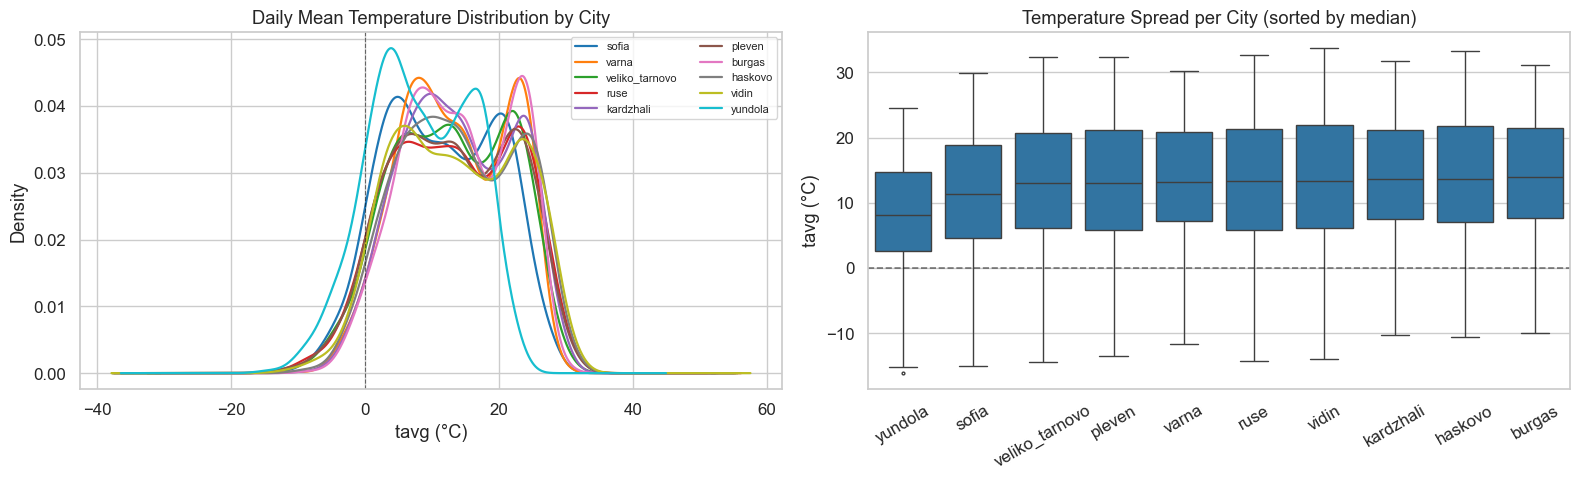

Saved: tavg_distributions.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# KDE overlay: all cities on one axis
ax = axes[0]
for city, df in city_dfs.items():
    df['tavg'].plot.kde(ax=ax, label=city, linewidth=1.6)
ax.set_title('Daily Mean Temperature Distribution by City')
ax.set_xlabel('tavg (°C)')
ax.set_ylabel('Density')
ax.legend(fontsize=8, ncol=2)
ax.axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

# Box plot: spread and outliers per city
ax = axes[1]
all_tavg = pd.concat(
    [df[['tavg']].assign(city=city) for city, df in city_dfs.items()]
)
city_order = all_tavg.groupby('city')['tavg'].median().sort_values().index.tolist()
sns.boxplot(data=all_tavg, x='city', y='tavg', order=city_order, flierprops={'markersize': 2}, ax=ax)
ax.set_title('Temperature Spread per City (sorted by median)')
ax.set_xlabel('')
ax.set_ylabel('tavg (°C)')
ax.tick_params(axis='x', rotation=30)
ax.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'tavg_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: tavg_distributions.png')

#### Observations

**KDE plot (left):** All three assumptions are confirmed:
- **Yundola** (1213 m) is shifted ~ 8-10°C colder than the lowland cities and has a wider, flatter distribution reflecting the alpine climate. A mild bimodal shape (cold-winter and warm-summer modes) is visible.
- **Coastal cities (Varna, Burgas)** show compressed, slightly right-shifted distributions. The Black Sea moderates both cold extremes in winter and heat extremes in summer, producing narrower tails than their inland counterparts at similar latitude.
- **Inland cities (Ruse, Vidin, Pleven, Haskovo)** sit in the middle range with broader tails, consistent with greater continental temperature variance and no maritime buffer.

The near-zero crossing present in all distributions confirms that sub-zero temperatures occur across all cities in winter not just Yundola. Any frost-risk feature should be engineered for every city in the dataset.

**Box plot (right):** The sorted order (coldest to warmest median) makes the elevation gradient immediately readable. Yundola is an isolated outlier at the cold end. The interquartile ranges for coastal cities are visibly narrower than for inland cities at similar elevation, confirming maritime moderation beyond just a mean shift.

**Conclusion:** `elev` and `coastal` are validated as informative geographic features. A single shared temperature distribution assumption would be incorrect the multi-city model must encode geographic context explicitly.

#### Precipitation & Rain: Distribution and Zero-Inflation
Precipitation is the key variable for the binary rain-prediction task. Two properties matter to be examined here:

1. **Zero-inflation** - most days have zero precipitation. This will produce severe class imbalance in the classifier and must be quantified now.
2. **Heavy-tail skew** - on wet days, rain amounts follow a log-normal or gamma distribution. Knowing this informs whether raw `prcp` or `log(1 + prcp)` should enter regression targets.

The approach used will follow the fraction of dry days and plot the rain-day distribution separately, consistent with the two-step 'occurrence + amount' decomposition standard defined in meteorological ML [2]

In [9]:
print('Dry-day fraction (prcp == 0) per city:')
dry_stats = []
for city, df in city_dfs.items():
    n_total = len(df)
    n_dry = (df['prcp'] == 0).sum()
    n_wet = n_total - n_dry
    dry_pct = 100 * n_dry / n_total
    print(f'  {city:20s}  dry={n_dry:4d} ({dry_pct:.1f}%)  wet={n_wet:4d} ({100-dry_pct:.1f}%)')
    dry_stats.append({'city': city, 'dry_pct': dry_pct, 'wet_pct': 100 - dry_pct})

dry_df = pd.DataFrame(dry_stats).set_index('city').sort_values('dry_pct')

Dry-day fraction (prcp == 0) per city:
  sofia                 dry=2015 (53.4%)  wet=1759 (46.6%)
  varna                 dry=2098 (55.6%)  wet=1676 (44.4%)
  veliko_tarnovo        dry=2053 (54.4%)  wet=1721 (45.6%)
  ruse                  dry=2171 (57.5%)  wet=1603 (42.5%)
  kardzhali             dry=2060 (54.6%)  wet=1714 (45.4%)
  pleven                dry=2159 (57.2%)  wet=1615 (42.8%)
  burgas                dry=2178 (57.7%)  wet=1596 (42.3%)
  haskovo               dry=2151 (57.0%)  wet=1623 (43.0%)
  vidin                 dry=2243 (59.4%)  wet=1531 (40.6%)
  yundola               dry=1644 (43.6%)  wet=2130 (56.4%)


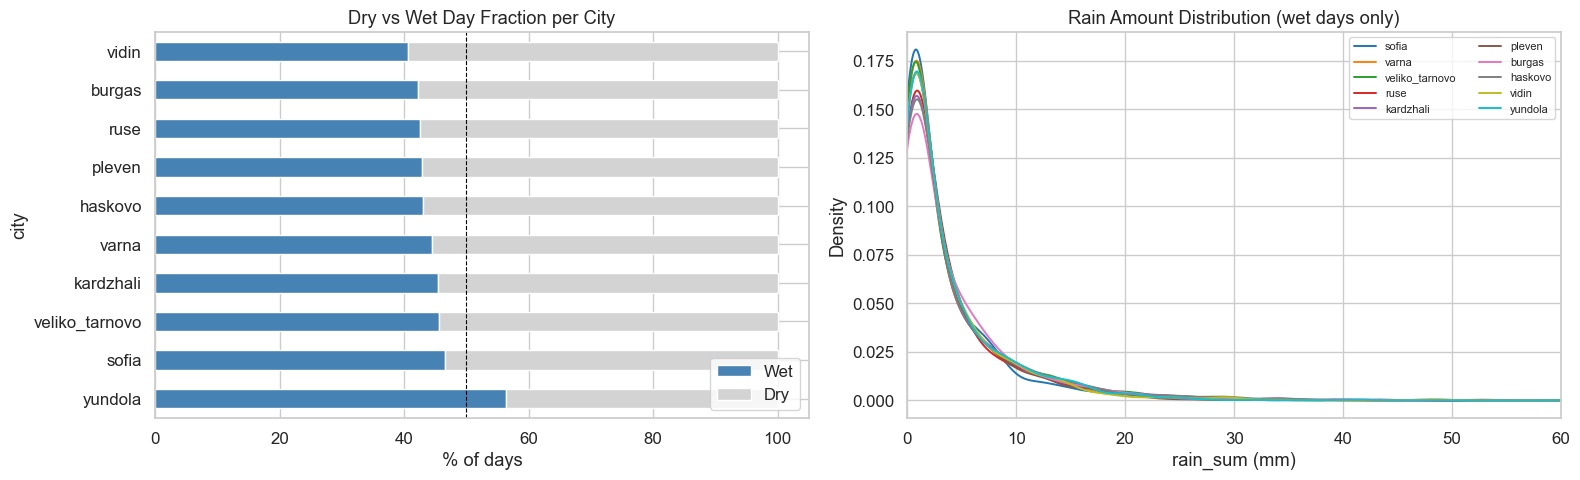

Saved: precipitation_distributions.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Dry vs wet day balance
dry_df[['wet_pct', 'dry_pct']].plot(
    kind='barh', stacked=True, ax=axes[0],
    color=['steelblue', 'lightgray'], edgecolor='white'
)
axes[0].set_title('Dry vs Wet Day Fraction per City')
axes[0].set_xlabel('% of days')
axes[0].legend(['Wet', 'Dry'], loc='lower right')
axes[0].axvline(50, color='black', linestyle='--', linewidth=0.8)

# Rain amount distribution on wet days only (log scale to reveal tail)
ax = axes[1]
for city, df in city_dfs.items():
    wet = df.loc[df['rain'] > 0, 'rain']
    wet.plot.kde(ax=ax, label=city, linewidth=1.4)
ax.set_xlim(0, 60)
ax.set_title('Rain Amount Distribution (wet days only)')
ax.set_xlabel('rain_sum (mm)')
ax.set_ylabel('Density')
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'precipitation_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: precipitation_distributions.png')

#### Observations

**Dry vs wet bar chart (left):** Most cities are dry on roughly 60-65% of days, confirming the class imbalance concern raised in section 6. Key patterns:
- **Yundola** has the lowest dry-day fraction as the wettest city in the dataset, consistent with alpine precipitation caused by the Rhodope terrain.
- **Coastal cities (Varna, Burgas)** also trend wetter than the inland average, reflecting Black Sea moisture.
- **Inland continental cities (Ruse, Vidin, Pleven)** show the highest dry-day fractions, consistent with the rain-shadow effect and dry summer regimes.

**Rain-day KDE (right):** On wet days, all cities produce a strongly right-skewed distribution with the bulk of events below 15-20 mm/day and a long tail extending to 50+ mm. This shape is consistent with a log-normal or gamma distribution. The city-to-city distributions largely overlap, meaning the key inter-city difference is **frequency** of rain (dry-day fraction), not **intensity** on wet days.

**Implication for modelling:** A naive classifier predicting "no rain" every day would achieve ~60-65% accuracy with zero skill. Better approach would be to use stratified splits and class-weighting or oversampling (e.g. SMOTE) to ensure the model learns the wet-day signal, not just the majority class.

#### Seasonal Patterns

Seasonal structure is the dominant signal in weather data. This part will visualize monthly mean `tavg` and monthly total `prcp` for all cities simultaneously. This serves two purposes:

1. **Sanity check:** Does the seasonal cycle look physically reasonable? (Summer peak in July–August, winter trough in January.)
2. **Feature engineering signal:** The presence of strong seasonality justifies adding calendar features (month, day-of-year, sine/cosine encoding) and lagged rolling means.

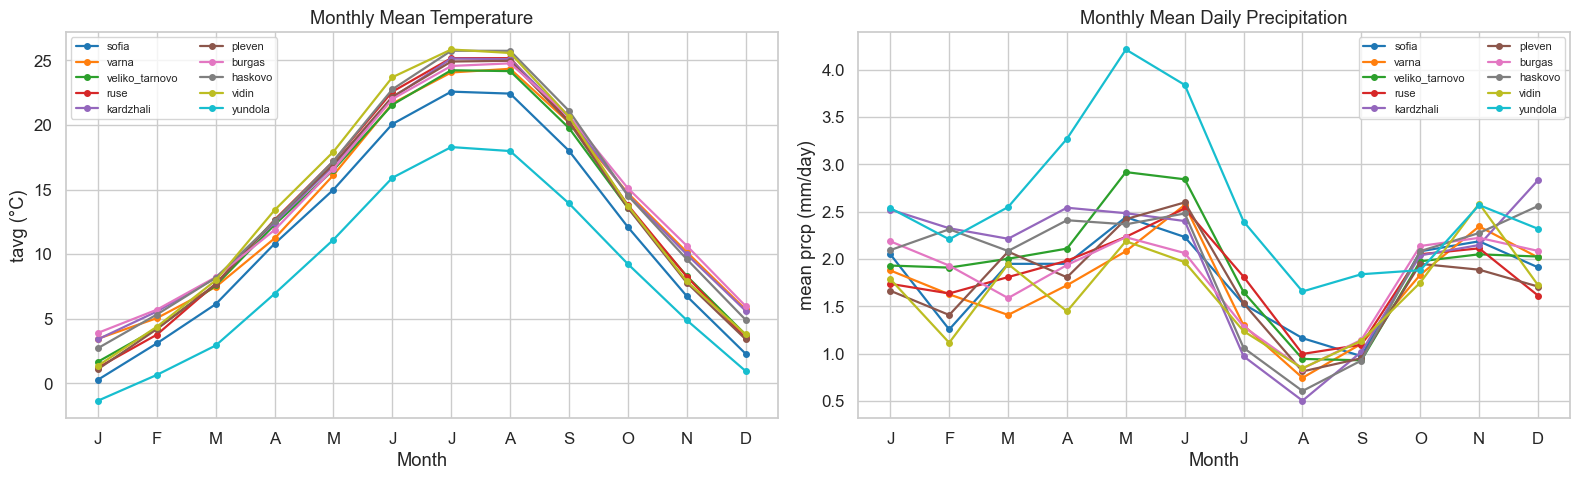

Saved: seasonal_patterns.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for city, df in city_dfs.items():
    monthly = df.groupby(df.index.month)
    axes[0].plot(range(1, 13), monthly['tavg'].mean().values,
                 marker='o', markersize=4, label=city, linewidth=1.6)
    axes[1].plot(range(1, 13), monthly['prcp'].mean().values,
                 marker='o', markersize=4, label=city, linewidth=1.6)

for ax, title, ylabel in zip(
    axes,
    ['Monthly Mean Temperature', 'Monthly Mean Daily Precipitation'],
    ['tavg (°C)', 'mean prcp (mm/day)']
):
    ax.set_title(title)
    ax.set_xlabel('Month')
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
    ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'seasonal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: seasonal_patterns.png')

#### Observations

**Monthly mean temperature (left):** All cities follow the expected temperate continental cycle trough in January, peak in July/August and the sanity check passes cleanly. Notable patterns:
- Yundola is consistently coldest across all months and shows a wider seasonal amplitude than the lowland cities.
- Coastal cities (Varna, Burgas) show a slightly **delayed autumn cooling** into October compared to inland cities which is consistent with the Black Sea's thermal inertia releasing stored summer heat into autumn. This lag is a subtle but real regime difference that `coastal` alone cannot encode; a lagged sea-surface-temperature proxy could be useful.
- The ~20–25°C seasonal amplitude (January minimum to July mean) across lowland cities confirms that `sin/cos(day_of_year)` calendar features will carry the single largest share of explained variance in temperature forecasting.

**Monthly mean precipitation (right):** Precipitation seasonality is more complex and city-specific than temperature:
- Most inland cities show a **spring maximum (May-June)** from convective thunderstorm activity and a secondary autumn peak.
- Yundola has elevated precipitation across all seasons, with the highest monthly totals overall.
- Coastal cities show a more pronounced **autumn–winter secondary peak**, consistent with Mediterranean cyclone influence over the Black Sea.

The absence of a single dominant dry season means a simple binary "summer/winter" indicator would not be sufficient. Rolling precipitation sums over 7–14 days will capture the multi-month moisture memory that `soil_moist` already partially encodes.

#### Correlation with Target (`tavg`): Sofia Case Study

This section will explore Pearson correlation of all variables against `tavg` for Sofia as a representative city. This directly tells us which raw features have predictive signal *before* any lag or rolling transformation. Sofia is chosen as a representative city because it occupies the middle ground across Bulgaria's climate spectrum: at 555m elevation. This makes Sofia a typifying case for the continental inland climate that characterizes most of Bulgaria, avoiding both extreme conditions (like Yundola's alpine regime) and outlier maritime moderation (like Varna and Burgas), so its correlation patterns generalize reasonably to the broader dataset before leave-one-city-out validation in later

**Interpretation guide:**
- `|r| > 0.7` - strong linear signal; likely direct candidate for inclusion.
- `0.4 < |r| < 0.7` - moderate signal; worth engineering lags of.
- `|r| < 0.2` - weak direct linear signal; may still be useful via non-linear interactions or as lag features.

**Caveat:** Pearson r captures only linear relationships. `wdir` (circular variable 0-360°) will show near-zero r even if it carries information it needs sine/cosine decomposition first.

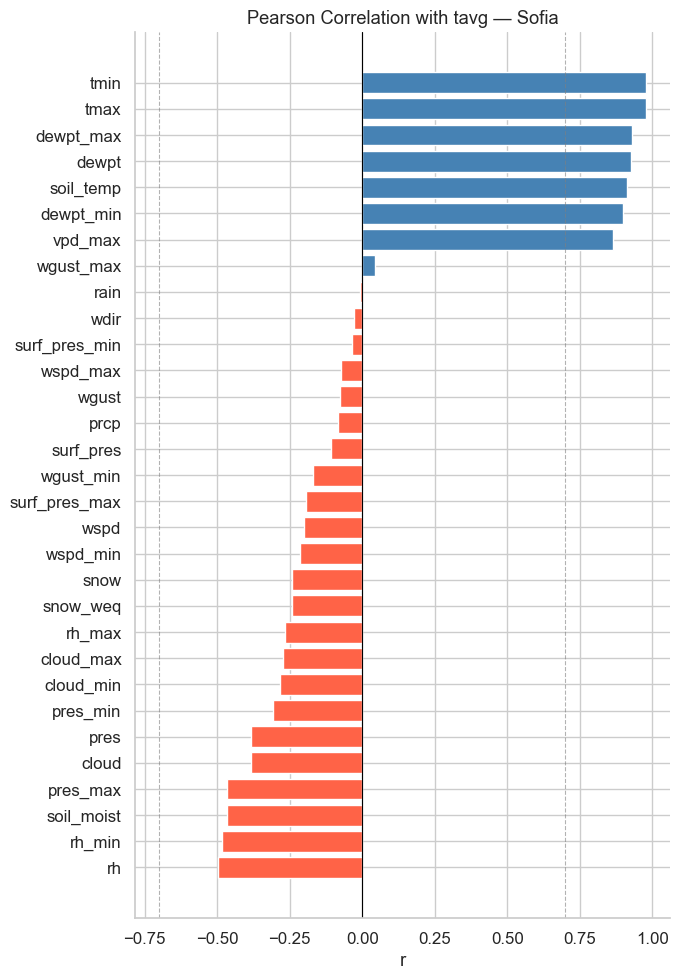

Saved: correlation_tavg_sofia.png

Top positive correlates with tavg:
wgust_max    0.044033
vpd_max      0.864158
dewpt_min    0.899773
soil_temp    0.914207
dewpt        0.927024
dewpt_max    0.931623
tmax         0.978337
tmin         0.978667

Top negative correlates with tavg:
rh           -0.496220
rh_min       -0.483707
soil_moist   -0.467799
pres_max     -0.464534
cloud        -0.384309


In [12]:
corr_city = 'sofia'
df_corr = city_dfs[corr_city].drop(columns=['city'])
corr_with_target = df_corr.corr()['tavg'].drop('tavg').sort_values()

fig, ax = plt.subplots(figsize=(7, 10))
colors = ['tomato' if v < 0 else 'steelblue' for v in corr_with_target.values]
ax.barh(corr_with_target.index, corr_with_target.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(0.7, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
ax.axvline(-0.7, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
ax.set_title(f'Pearson Correlation with tavg — {corr_city.capitalize()}')
ax.set_xlabel('r')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f'correlation_tavg_{corr_city}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: correlation_tavg_{corr_city}.png')

print(f'\nTop positive correlates with tavg:')
print(corr_with_target.tail(8).to_string())
print(f'\nTop negative correlates with tavg:')
print(corr_with_target.head(5).to_string())

#### Observations

**Strong positive predictors (r > 0.7):** `soil_temp`, `dewpt`, `tmax`, `tmin`. These variables directly encode the temperature regime `tmax`/`tmin` as same-day bounds, `dewpt` through the moisture-temperature coupling, and `soil_temp` through the deep thermal inertia of the ground. All are high-importance raw features before any lag transformation.

**Strong negative predictors:** `pres` shows strong negative correlation with `tavg`, confirming the critical synoptic signal discussed earlier. Winter anticyclones produce cold, clear days; summer pressure troughs bring warm, unsettled weather. `cloud_min` and `rh_max` are also negatively correlated, consistent with clear-sky nights losing heat to radiation (low overnight cloud = colder minimum temperatures).

**Moderate signal - value is in the lagged form:**
- `soil_moist` shows moderate negative r at t=0 wetter soil is associated with cooler, cloudier conditions. Its primary predictive value is as a lagged feature (5-16 day memory window [2]), not the same-day value shown here.
- `vpd_max` shows moderate positive r, driven almost entirely by warm-season data. In winter it is near zero, so it functions as a warm-season-only predictor.

**Near-zero confirms the circular variable issue:**
- `wdir` shows near-zero r with `tavg` as anticipated. This is **not** evidence of low predictive value, it is evidence that Pearson r is the wrong statistic for a 0-360° circular variable. The sin/cos decomposition is mandatory before evaluating `wdir`'s contribution.
- `prcp` and `rain` show near-zero r with `tavg`, which is expected, precipitation occurrence has no direct linear relationship with daily mean temperature in a temperate climate.

#### Full Correlation Heatmap for Sofia

The full inter-variable correlation matrix reveals multicollinearity between predictors a critical concern for linear models (Ridge, Lasso) and for interpreting feature importances in tree models.

**What to look for:**
- Blocks of high inter-correlation (e.g. `tmax/tmin/tavg`, `pres/surf_pres`, all wind triplets) in feature engineering it might be needed to select within groups to avoid redundant features.
- `pres` vs `cloud` - negative correlation expected (high pressure = clear sky).
- `soil_moist` vs `prcp` - lagged moisture should correlate with recent precipitation.

Masking the upper triangle in order to reduce visual clutter.

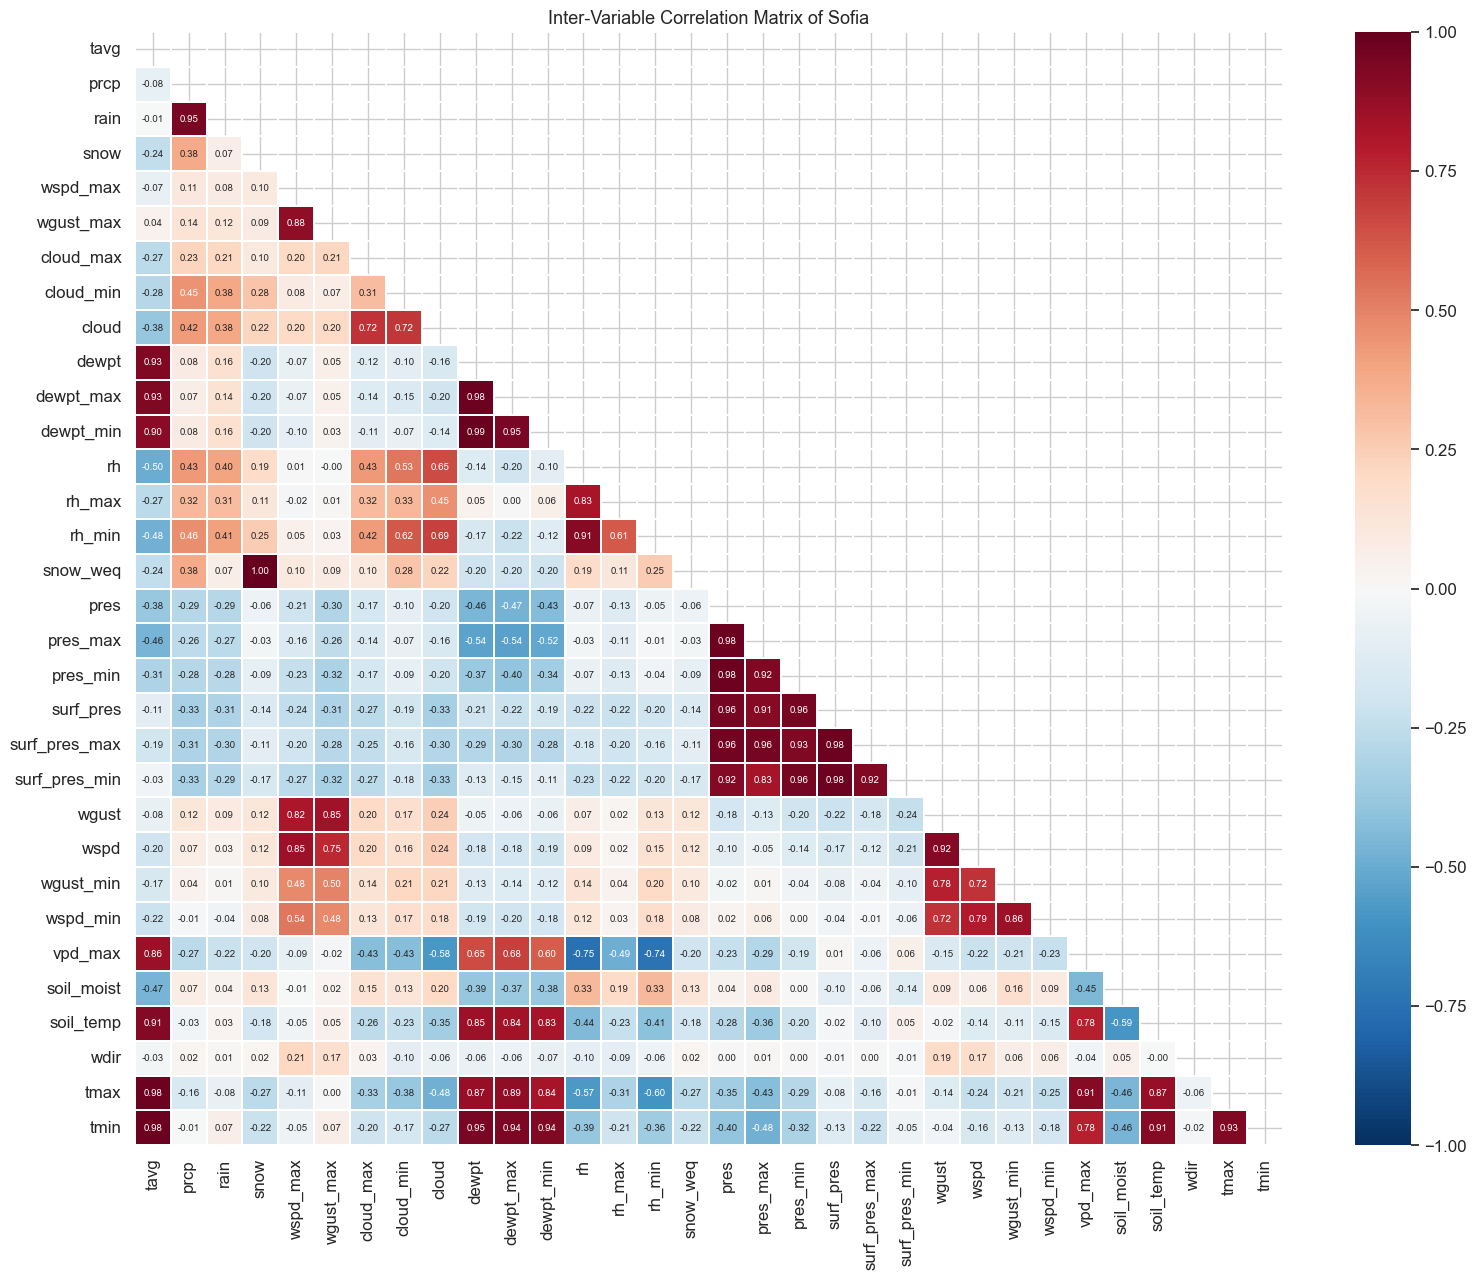

Saved: correlation_heatmap_sofia.png


In [13]:
df_heat = city_dfs['sofia'].drop(columns=['city'])
corr_matrix = df_heat.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', annot_kws={'size': 7}, cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.3, ax=ax
)
ax.set_title('Inter-Variable Correlation Matrix of Sofia', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlation_heatmap_sofia.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: correlation_heatmap_sofia.png')

#### Observations

| Group | Observed r | Conclusion |
|---|---|---|
| Temperature (`tavg`, `tmax`, `tmin`) | > 0.97 | All three kept as targets/proxies; never all three as simultaneous predictors |
| Pressure (`pres`, `surf_pres`, `pres_max/min`) | > 0.95 | `surf_pres` is barometrically altitude-corrected `pres` - highly redundant; drop confirmed |
| Humidity (`rh`, `rh_max/min`, `dewpt`, `dewpt_max/min`) | ≈ 0.85–0.95 | Mean values (`rh`, `dewpt`) capture bulk variance; max/min sub-variables drop confirmed |
| Cloud cover (`cloud`, `cloud_max`, `cloud_min`) | > 0.85 | Mean sufficient; drop confirmed |
| Wind (`wspd`, `wgust`, `wgust_max`, `wspd_min`) | ≈ 0.70-0.85 | `wgust_max` retains the extreme-tail information missing from the mean |

**Cross-group relationships:**
- **`pres` vs `cloud`:** Negative correlation confirmed - high pressure associates with clear-sky conditions. This is the primary synoptic coupling in the dataset and is physically expected (anticyclonic subsidence inhibits cloud formation).
- **`soil_moist` vs `prcp`:** Positive, moderate - soil moisture integrates recent accumulated precipitation over a multi-day window. This lagged integration is exactly why `soil_moist` carries medium-range forecast skill beyond raw precipitation.

**VIF next step:** Within-group r values above 0.9 will produce variance inflation factors well above the standard threshold of 5. In the next steps of the project a VIF will be ran after initial feature selection to confirm which sub-variables to drop, and to catch any cross-group multicollinearity that block-level correlation does not reveal.

#### Outlier Detection

For the outlier detection, I will use the IQR fence method (Tukey, 1977), widened to **3.0×IQR**, any value below `Q1 - 3.0×IQR` or above `Q3 + 3.0×IQR` will be flagged. The standard 1.5×IQR fence marks *mild* outliers, which for these heavily-skewed weather variables would flag a large fraction of probably normal rainy/windy days. Since the goal here is specifically to identify **extreme-event days** (severe storms, heavy snowfall, major wind events), the 3.0×IQR "extreme outlier" fence is the more appropriate threshold as it isolates the genuinely unusual tail rather than ordinary distribution skew. This is a non-parametric method: it makes no assumption about normality, which is appropriate here because precipitation and wind variables are heavily skewed.

**Importantly, for reanalysis data**, outliers are almost certainly physically real (e.g. an actual severe storm). The goal here is to:
- Confirm there are no *instrument errors* or *data entry errors* (values outside physical plausibility bounds).
- Quantify how much of each variable's range consists of extreme-event days this informs whether tree-based models (which handle outliers natively) or linear models (which may need robust scaling) are better default choices.

Below is a report of the extreme-outlier count per variable for each city, and then visualisization of the key variables with box plots.

#### Physical Plausibility Thresholds

`BOUNDS` is intentionally **independent of the 3.0×IQR fence above** the IQR fence flags *statistically rare* days within this dataset, while `BOUNDS` checks for *physically impossible* values (sensor errors, unit mistakes, sentinel codes like `-999`/`9999`). Each bound below is set from the dataset's own observed min/max (10 cities, 2016–2026) plus a physically-justified margin for genuine extremes the 10-year sample may not contain.

| Variable | Observed range | 3.0×IQR fence | `BOUNDS` | Reasoning |
|---|---|---|---|---|
| `tavg` | -16.1 to 33.7 °C | -36.6 to 62.8 | **(-40, 45)** | Observed range sits comfortably inside. Lower bound (-40°C) matches Bulgaria's all-time record low (-38.3°C, Tran 1947), giving headroom for an extreme winter not seen in 2016–2026. Upper bound (45°C) matches the national record high (Sadovo 1916) — `tavg` (the *daily mean*) realistically can't exceed this even in the most extreme heatwave. |
| `tmax` | -13.0 to 43.3 °C | -34.1 to 70.2 | **(-35, 48)** | Observed max (43.3°C) is close to the national daily-max record (~45°C); 48°C adds a small margin for a future record-breaking heatwave. The IQR fence's upper bound (70.2°C) is meteorologically impossible for this region, confirming the IQR fence alone is too loose here. Lower bound -35°C is intentionally looser than `tmin`'s, since a *daily maximum* this cold is already an extreme cold-air event. |
| `tmin` | -25.3 to 26.9 °C | -36.8 to 54.2 | **(-40, 40)** | -40°C again anchors to the national record low with a small safety margin. Upper bound 40°C allows for an unusually warm overnight minimum during a heatwave (tropical nights), which is rare but physically possible and not observed in this dataset. |
| `prcp` | 0.0 to 95.9 mm | -4.2 to 5.6 | **(0, 250)** | Lower bound 0 is definitional precipitation cannot be negative. The 3.0×IQR upper fence (5.6mm) is far *below* the observed maximum (95.9mm) because most days are dry, collapsing the IQR — this confirms the IQR fence is meaningless for zero-inflated variables. 250mm/day allows for a genuine extreme flood event (Bulgaria has recorded >150–200mm/day during severe storms) well above the observed 95.9mm, while still catching obvious data errors. |
| `rain` | 0.0 to 95.9 mm | -3.0 to 4.0 | **(0, 250)** | Same reasoning as `prcp` - `rain` is the liquid-precipitation component and shares the same zero-inflated distribution and physical ceiling. |
| `snow` | 0.0 to 34.9 cm | 0.0 to 0.0 | **(0, 80)** | The 3.0×IQR fence collapses to exactly (0, 0) because the median, Q1, and Q3 are all 0 (snow-free days dominate even in winter) any nonzero snowfall would be "flagged," making the IQR fence completely unusable here. 80cm/day is a generous ceiling for a single extreme blizzard event at Yundola's elevation (1213m), roughly 2.3× the observed maximum. |
| `pres` | 990.1 to 1043.4 hPa | 985.6 to 1047.9 | **(960, 1055)** | This is the one variable where the 3.0×IQR fence is itself physically reasonable (pressure is approximately normally distributed, so IQR-based fences behave well). `BOUNDS` widens it slightly further (960–1055 hPa) to cover the deepest cyclones and strongest anticyclones possible at this latitude that simply didn't occur in the 2016–2026 sample, while still rejecting sensor faults. |
| `rh` | 24.0 to 100.0 % | 1.0 to 141.0 | **(0, 100)** | `rh` is a percentage by definition, so (0, 100) is the only valid range. The 3.0×IQR fence's upper bound (141%) is physically impossible — humidity is capped at 100% (saturation) and the dataset is heavily skewed toward that ceiling, which inflates Q3 and the IQR. This is a clear example of why the IQR fence cannot replace a definitional bound. |
| `cloud` | 0.0 to 100.0 % | -157.0 to 256.0 | **(0, 100)** | Same logic as `rh` - cloud cover is a percentage, hard-bounded at (0, 100). The IQR fence is wildly out of range in both directions (cloud cover is bimodal often near 0% or near 100% which produces a large IQR and a nonsensical fence), reinforcing that this check must come from the variable's definition, not its distribution. |
| `wdir` | 0.0 to 360.0 ° | -542.0 to 893.0 | **(0, 360)** | Wind direction is a circular variable (0° and 360° are the same heading), so (0, 360) is the definitional bound. The IQR fence is meaningless here (as flagged in Section 15) — a circular quantity has no linear "spread," so Tukey's fence produces bounds far outside the 0–360° domain. |

The IQR check and the `BOUNDS` check serve different purposes and are deliberately kept separate. IQR finds *statistically unusual days* for outlier analysis; `BOUNDS` finds *impossible values* for data-quality assurance. For bounded/percentage variables (`rh`, `cloud`, `wdir`) and zero-inflated variables (`prcp`, `rain`, `snow`), the IQR fence is not a valid plausibility check at all `BOUNDS` must come from the variable's physical definition or known regional climate extremes instead.

In [14]:
def iqr_outlier_count(series: pd.Series) -> int:
    """Count values outside Tukey's 3.0×IQR \"extreme outlier\" fence."""
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return int(((series < q1 - 3.0 * iqr) | (series > q3 + 3.0 * iqr)).sum())


outlier_records = []
for city, df in city_dfs.items():
    numeric_cols = [c for c in df.columns if c != 'city']
    row = {'city': city}
    for col in numeric_cols:
        row[col] = iqr_outlier_count(df[col])
    outlier_records.append(row)

outlier_df = pd.DataFrame(outlier_records).set_index('city')

# Show top-outlier variables across all cities
total_outliers = outlier_df.sum(axis=0).sort_values(ascending=False)
print('Total extreme-outlier (3.0×IQR) count across all cities, by variable:')
print(total_outliers.to_string())

# Physical plausibility check
BOUNDS = {
    'tavg': (-40, 45), 'tmax': (-35, 48), 'tmin': (-40, 40),
    'prcp': (0, 250),  'rain': (0, 250),   'snow': (0, 80),
    'pres': (960, 1055), 'rh': (0, 100),    'cloud': (0, 100),
    'wdir': (0, 360),
}
print('Physical plausibility check:')
violations_found = False
for city, df in city_dfs.items():
    for var, (lo, hi) in BOUNDS.items():
        if var not in df.columns:
            continue
        bad = df.loc[(df[var] < lo) | (df[var] > hi), var]
        if len(bad) > 0:
            print(f'  {city} / {var}: {len(bad)} values outside [{lo}, {hi}]')
            print(bad.head(3))
            violations_found = True
if not violations_found:
    print('All variables within physical bounds.')

Total extreme-outlier (3.0×IQR) count across all cities, by variable:
rain             4760
prcp             4436
cloud_min        4306
cloud_max        4221
snow             2591
snow_weq         2591
wgust_min         420
wspd_min          213
wgust              87
wspd               77
rh_max             38
wspd_max           28
wgust_max          27
surf_pres_min       7
vpd_max             7
pres_min            5
tavg                0
soil_moist          0
wdir                0
tmax                0
soil_temp           0
pres                0
surf_pres_max       0
surf_pres           0
pres_max            0
rh_min              0
rh                  0
dewpt_min           0
dewpt_max           0
dewpt               0
cloud               0
tmin                0
Physical plausibility check:
All variables within physical bounds.


I will now eplore the box plots for `prcp`, `wspd_max`, `wgust_max`, and `snow` because their outliers correspond to real extreme-weather days (storms, gusts, heavy snowfall) which corresponds to the analysis on extreme-event behaviour.

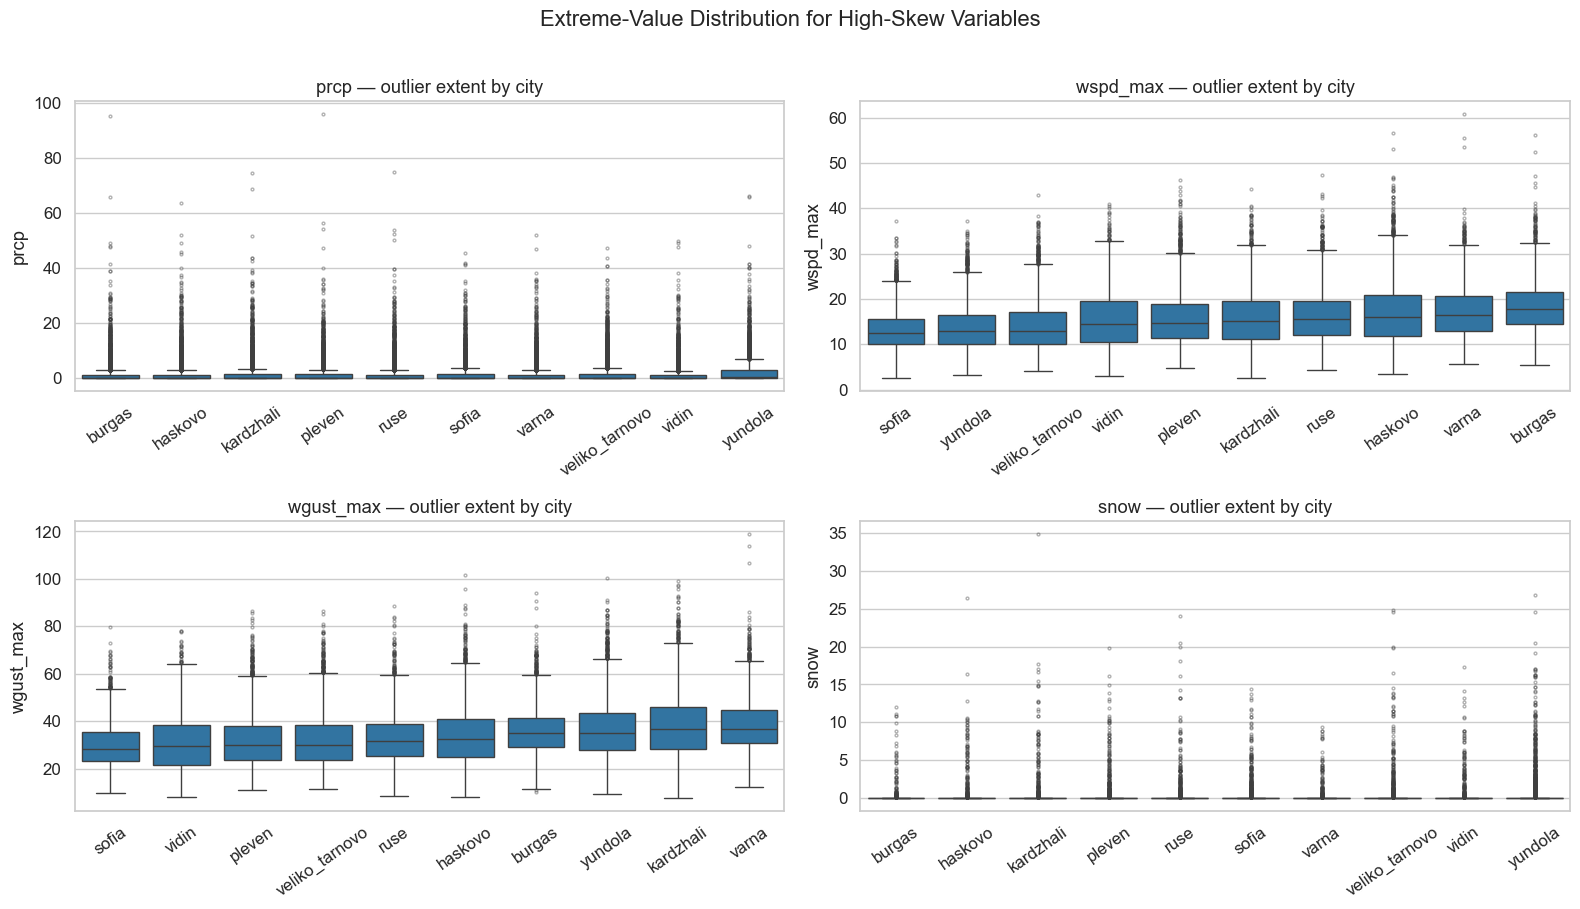

Saved: outlier_boxplots.png


In [15]:
# Box plots for key variables across cities to visualise outlier extent
PLOT_VARS = ['prcp', 'wspd_max', 'wgust_max', 'snow']

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
all_data = pd.concat(list(city_dfs.values()))

for ax, var in zip(axes.flatten(), PLOT_VARS):
    city_order = all_data.groupby('city')[var].median().sort_values().index.tolist()
    sns.boxplot(data=all_data, x='city', y=var, order=city_order, flierprops={'markersize': 2, 'alpha': 0.4}, ax=ax)
    ax.set_title(f'{var} — outlier extent by city')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=35)

plt.suptitle('Extreme-Value Distribution for High-Skew Variables', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outlier_boxplots.png')

#### Observations

**Physical plausibility check:** All variables pass, no values outside hard meteorological bounds. The ERA5 reanalysis quality control is effective for this dataset; no rows need to be removed.

**Extreme-outlier counts (3.0×IQR):** Even at this stricter fence, the highest counts still belong to the right-skewed variables predicted in section 6: `prcp`, `rain`, `snow`, `wgust_max`, and `wspd_max`. Moving from the 1.5×IQR "mild outlier" fence to the 3.0×IQR "extreme outlier" fence sharply reduces the counts for all variables, but the variables that remain flagged represent the genuinely rare tail the actual severe-storm, heavy-snowfall, and major-wind-event days rather than ordinary rainy or breezy days that the 1.5× fence would've over-flagged. These remaining points are not data errors; this is the expected result for reanalysis data.

**Box plots — key observations:**
- **`prcp`:** Even under the wider 3.0×IQR fence, high-precipitation days remain flagged across all cities; some days reach 3-5× the 75th percentile. Yundola typically shows the most extreme precipitation outliers, consistent with its orographic exposure (moisture forced upward by the Rhodope terrain).
- **`wgust_max`:** Long upper tail across all cities; coastal cities (Varna, Burgas) tend toward higher gusts, consistent with exposure to Black Sea cyclonic systems.
- **`snow`:** Outliers are concentrated in winter months and more pronounced for Yundola and Sofia (higher elevation). Coastal cities show minimal snow, consistent with their mild winter regime.
- **`wspd_max`:** Less extreme than gusts but still right-skewed; Yundola shows the widest range due to exposure at ridge elevation.

**Model choice implication:** Using the 3.0×IQR "extreme outlier" fence better isolates true extreme-event days without over-flagging routine skewed-but-normal observations, which is the more useful signal for this project's focus on extreme-event behaviour. For linear models, `log(1+x)` on precipitation variables and `sqrt` on wind variables substantially reduce leverage from these extreme points. Tree-based models are robust without transformation but transformation may still help calibration on extreme-event days.

#### Cross-City Climate Diversity

For a multi-city model to generalise, the cities must differ meaningfully. In order to explore this option I will visualise two dimensions of climate diversity:

1. **Annual temperature range** (`tmax` - `tmin` seasonal spread) which distinguishes continental from coastal climates.
2. **Annual precipitation total** which distinguishes dry from wet climates.

I will also compare mean annual temperature against elevation to look for an elevation–temperature gradient across the 10 stations. 

**A note before looking at the numbers:** the commonly-cited “environmental lapse rate” (~6.5°C per 1000 m, see the [NWS lapse-rate / instability primer](https://www.weather.gov/lmk/indices)) describes the vertical temperature profile of the free atmosphere above a single location. It's measured by radiosondes ascending through one air column, and is used for stability indices (CAPE, etc.), not as a benchmark for how 10 different surface stations at different latitudes and distances from the sea should compare to each other. There is no reason to expect a cross-station regression of station elevation against station mean temperature to reproduce that figure. I will compute the gradient empirically below and interpret it on its own terms, alongside the `coastal` and basin/topography effects already identified in earlier sections. What would validate `elev` as a useful geographic feature is a clear *negative* relationship of some magnitude, not agreement with 6.5°C/1000 m.

In [16]:
annual_records = []
for city, df in city_dfs.items():
    meta = CITY_METADATA[city]
    annual_records.append({
        'city': city,
        'lat': meta['lat'],
        'lon': meta['lon'],
        'elev': meta['elev'],
        'climate_zone': meta['climate_zone'],
        'coastal': int(meta['climate_zone'] == 'coastal_maritime'),
        'mean_tavg': df['tavg'].mean(),
        'mean_tmax': df['tmax'].mean(),
        'mean_tmin': df['tmin'].mean(),
        'annual_prcp_mean': df['prcp'].resample('YE').sum().mean(),
        'diurnal_range_mean': (df['tmax'] - df['tmin']).mean(),
    })

climate_df = pd.DataFrame(annual_records).set_index('city')
display(climate_df.round(2))

,lat,lon,elev,climate_zone,coastal,mean_tavg,mean_tmax,mean_tmin,annual_prcp_mean,diurnal_range_mean
city,,,,,,,,,,
sofia,42.71,23.40,555,continental_plain,0,11.45,16.95,6.70,622.32,10.25
varna,43.22,27.92,68,coastal_maritime,1,13.50,17.40,10.13,588.70,7.26
veliko_tarnovo,43.13,25.62,226,subcontinental,0,12.96,18.17,8.23,666.32,9.94
ruse,43.83,26.01,36,danube_valley,0,13.26,18.19,8.84,617.78,9.34
kardzhali,41.65,25.36,248,continental_plain,0,13.95,19.15,9.20,689.62,9.95
pleven,43.41,24.56,96,continental_plain,0,13.12,18.07,8.65,595.87,9.42
burgas,42.57,27.44,32,coastal_maritime,1,14.00,18.62,9.98,619.82,8.64
haskovo,41.93,25.51,195,continental_plain,0,14.01,19.35,9.20,666.93,10.14
vidin,43.97,22.94,43,danube_valley,0,13.67,18.55,9.30,564.33,9.26


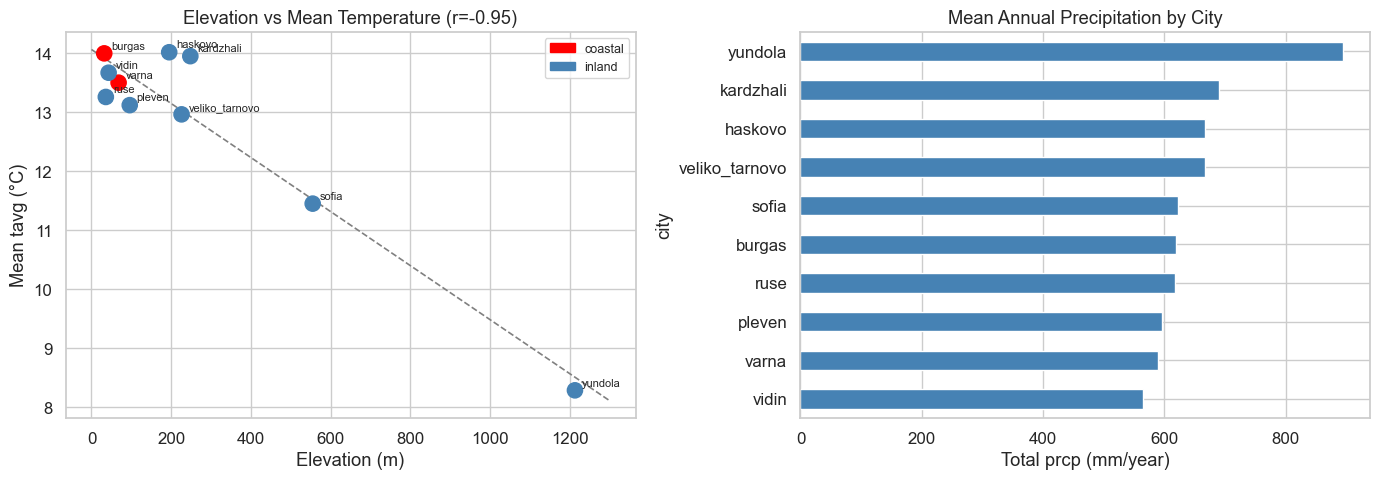

Saved: cross_city_climate.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elevation vs mean temperature: lapse rate validation
ax = axes[0]
colors_coast = ['red' if c == 1 else 'steelblue' for c in climate_df['coastal']]
ax.scatter(climate_df['elev'], climate_df['mean_tavg'], c=colors_coast, s=120, zorder=3)

# Fit a simple linear trend
slope, intercept, r, *_ = stats.linregress(climate_df['elev'], climate_df['mean_tavg'])
x_line = np.array([0, 1300])
ax.plot(x_line, slope * x_line + intercept, color='gray', linestyle='--', linewidth=1.2)
for city_name, row in climate_df.iterrows():
    ax.annotate(city_name, (row['elev'], row['mean_tavg']), textcoords='offset points', xytext=(5, 3), fontsize=8)
ax.set_title(f'Elevation vs Mean Temperature (r={r:.2f})')
ax.set_xlabel('Elevation (m)')
ax.set_ylabel('Mean tavg (°C)')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='red', label='coastal'), Patch(color='steelblue', label='inland')], fontsize=9)

# Annual precipitation total per city
ax = axes[1]
climate_df['annual_prcp_mean'].sort_values().plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Mean Annual Precipitation by City')
ax.set_xlabel('Total prcp (mm/year)')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cross_city_climate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cross_city_climate.png')

#### Observations

**Elevation vs mean temperature (left):** The cross-station slope is -4.57 °C/1000 m with negative relationship (r = -0.953), shallower than the 6.5 °C/1000 m free-atmosphere rate - exactly as anticipated earlier.

Coastal cities (Varna, Burgas, shown in red) sit **above** the regression line meaning warmer than elevation alone predicts. This is the maritime moderation signal: the Black Sea buffers cold air advection in winter and suppresses peak summer temperatures. The `coastal` flag captures exactly this residual.

Sofia sits slightly below the trendline despite its relatively modest elevation (555 m), reflecting its basin topography and tendency for cold-air pooling in winter anticyclones.

**Annual precipitation (right):**
- Yundola is the wettest city by a clear margin
- Coastal cities (Burgas, Varna) rank above the inland average
- The driest cities are inland and continental (Ruse, Vidin, Pleven), reflecting the rain-shadow of the Balkan mountain range

1. Elevation lapse rate: strong r, slope shallower than the free-air 6.5.
2. Maritime moderation: coastal cities above the trendline.
3. Continental dryness: inland cities at the low end of annual precipitation.

The 10-city dataset is climatically diverse enough to train and evaluate a multi-city model. A model trained without geographic encodings would systematically mis-predict Yundola's temperatures and the coastal cities' variance.

#### Temporal Stability: Interannual Variability

Finally, for the initially chosen train/validation/test split by date (2016-2023 / 2024 / Jan 2025-May 2026), the statistical properties of the data must be broadly consistent across years. I will now check whether any year stands out as anomalous in annual mean temperature: either a data artefact or a genuine climate signal (both are fine to know ahead of modelling). And also validate if this split would actilly be a good fit for this project or it will need a re-evaluation as it was chosen without relying on data but simple gut feeling.

I will also verify that there is no **distribution shift** between the training period and the held-out test period, which would make test-set generalisation harder to interpret. The Kolmogorov-Smirnov test was chosen because it compares the entire empirical CDFs of the train and test tavg samples, not just their means, so it catches shifts in spread or shape (e.g. fewer extreme cold days from warming) that a t-test would miss. It's distribution-free [2], making no Gaussian assumption, which matters since tavg is only roughly normal and has seasonal bimodality. Wilks also notes the K-S test is more powerful than a ${\chi}^2$ test for continuous data, avoiding the information loss and bin-width sensitivity that binning tavg for a ${\chi}^2$ test would introduce.

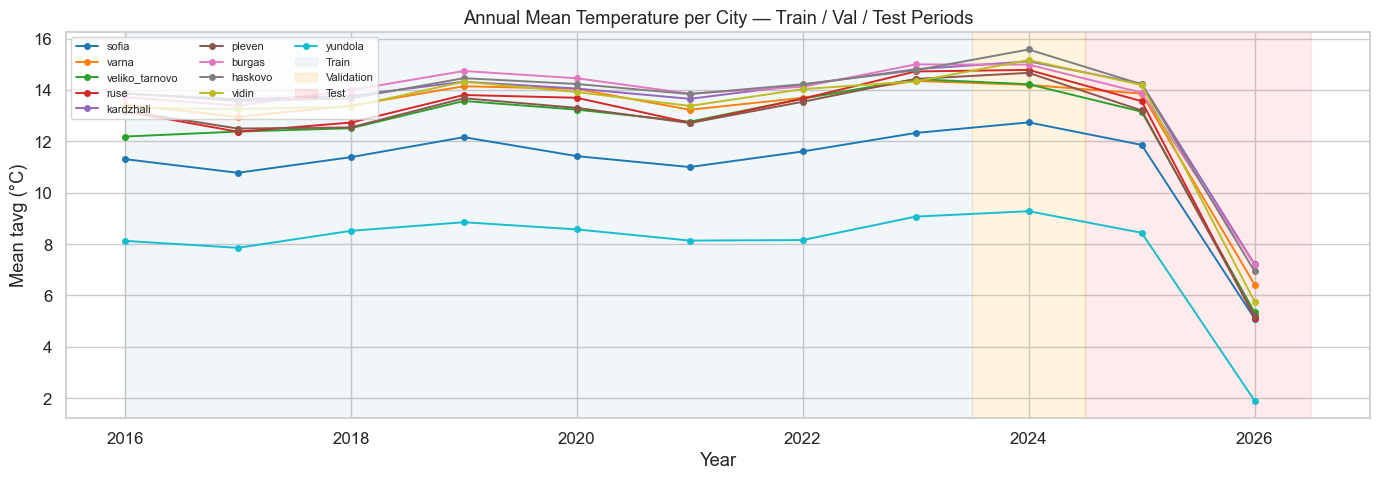

Saved: interannual_variability.png


In [18]:
# Annual mean tavg per city
fig, ax = plt.subplots(figsize=(14, 5))

for city, df in city_dfs.items():
    annual_mean = df['tavg'].resample('YE').mean()
    ax.plot(annual_mean.index.year, annual_mean.values, marker='o', markersize=4, label=city, linewidth=1.4)

ax.axvspan(2016, 2023.5, alpha=0.07, color='steelblue', label='Train')
ax.axvspan(2023.5, 2024.5, alpha=0.12, color='orange', label='Validation')
ax.axvspan(2024.5, 2026.5, alpha=0.08, color='red', label='Test')
ax.set_title('Annual Mean Temperature per City — Train / Val / Test Periods')
ax.set_xlabel('Year')
ax.set_ylabel('Mean tavg (°C)')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, fontsize=8, ncol=3, loc='upper left')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'interannual_variability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: interannual_variability.png')

In [19]:
# Kolmogorov-Smirnov test: does the test period tavg distribution differ from training?
print('KS test: training (2016-2023) vs test (2025-2026) tavg distribution')
print(f'{"City":20s}  {"KS stat":10s}  {"p-value":10s}  {"Shift?"}')
print('-' * 56)
for city, df in city_dfs.items():
    train_vals = df.loc[df.index <= TRAIN_END, 'tavg']
    test_vals  = df.loc[df.index > VAL_END,   'tavg']
    ks_stat, p_val = stats.ks_2samp(train_vals, test_vals)
    flag = 'YES (p<0.05)' if p_val < 0.05 else 'no'
    print(f'{city:20s} - {ks_stat:.4f} - {p_val:.8f} - {flag}')

KS test: training (2016-2023) vs test (2025-2026) tavg distribution
City                  KS stat     p-value     Shift?
--------------------------------------------------------
sofia                - 0.1257 - 0.00000336 - YES (p<0.05)
varna                - 0.1389 - 0.00000018 - YES (p<0.05)
veliko_tarnovo       - 0.1325 - 0.00000076 - YES (p<0.05)
ruse                 - 0.1379 - 0.00000022 - YES (p<0.05)
kardzhali            - 0.1332 - 0.00000065 - YES (p<0.05)
pleven               - 0.1350 - 0.00000043 - YES (p<0.05)
burgas               - 0.1520 - 0.00000001 - YES (p<0.05)
haskovo              - 0.1307 - 0.00000114 - YES (p<0.05)
vidin                - 0.1257 - 0.00000339 - YES (p<0.05)
yundola              - 0.1510 - 0.00000001 - YES (p<0.05)


This K-S test results in shift for all 10 cities which I assume might be coming from the initial test selection encompasing 16 months (Jan 2025 - May 2026) which includes additional winter and spring seasons. I will run a second K-S test to check what happens if the test selection is reduced to 12 months or a full year.

In [20]:
# Follow-up KS test: does a seasonally-balanced test window (calendar year 2025)
print('KS test: training (2016-2023) vs ORIGINAL test window (2025-01-01 to 2026-05-01)')
print(f'{"City":20s}  {"KS stat":10s}  {"p-value":10s}  {"Shift?"}')
print('-' * 56)
for city, df in city_dfs.items():
    train_vals = df.loc[df.index <= TRAIN_END, 'tavg']
    test_vals_orig = df.loc[df.index > VAL_END, 'tavg']
    ks_stat, p_val = stats.ks_2samp(train_vals, test_vals_orig)
    flag = 'YES (p<0.05)' if p_val < 0.05 else 'no'
    print(f'{city:20s} - {ks_stat:.4f} - {p_val:.8f} - {flag}')

print()
print('KS test: training (2016-2023) vs ALTERNATIVE test window (2025-01-01 to 2025-12-31)')
print(f'{"City":20s}  {"KS stat":10s}  {"p-value":10s}  {"Shift?"}')
print('-' * 56)
for city, df in city_dfs.items():
    train_vals = df.loc[df.index <= TRAIN_END, 'tavg']
    test_vals_2025 = df.loc[(df.index >= '2025-01-01') & (df.index <= '2025-12-31'), 'tavg']
    ks_stat, p_val = stats.ks_2samp(train_vals, test_vals_2025)
    flag = 'YES (p<0.05)' if p_val < 0.05 else 'no'
    print(f'{city:20s} - {ks_stat:.4f} - {p_val:.8f} - {flag}')

KS test: training (2016-2023) vs ORIGINAL test window (2025-01-01 to 2026-05-01)
City                  KS stat     p-value     Shift?
--------------------------------------------------------
sofia                - 0.1257 - 0.00000336 - YES (p<0.05)
varna                - 0.1389 - 0.00000018 - YES (p<0.05)
veliko_tarnovo       - 0.1325 - 0.00000076 - YES (p<0.05)
ruse                 - 0.1379 - 0.00000022 - YES (p<0.05)
kardzhali            - 0.1332 - 0.00000065 - YES (p<0.05)
pleven               - 0.1350 - 0.00000043 - YES (p<0.05)
burgas               - 0.1520 - 0.00000001 - YES (p<0.05)
haskovo              - 0.1307 - 0.00000114 - YES (p<0.05)
vidin                - 0.1257 - 0.00000339 - YES (p<0.05)
yundola              - 0.1510 - 0.00000001 - YES (p<0.05)

KS test: training (2016-2023) vs ALTERNATIVE test window (2025-01-01 to 2025-12-31)
City                  KS stat     p-value     Shift?
--------------------------------------------------------
sofia                - 0.0669 - 0.

#### Choice of Test Window

| | Original (2025-01-01 → 2026-05-01, 16 months) | Alternative (2025-01-01 → 2025-12-31, 12 months) |
|---|---|---|
| KS stat range | 0.125 - 0.152 | 0.037 - 0.075 |
| Significant shift (p < 0.05) | 10 / 10 cities | 1 / 10 cities (Vidin, p ≈ 0.049, borderline) |
| Seasonal composition | Jan-Apr double-weighted | Matches training exactly |
| Mean `tavg` vs. train | colder (calendar artefact) | comparable |

Restricting the test window to a full calendar year (2025) cuts the KS statistics and removes the statistically significant shift for 9 of 10 cities. This confirms the shift found above is driven almost entirely by the seasonal-composition imbalance of the originaly selected 16-month window, not by a genuine 2025-2026 climate anomaly.

**Conclusion:** I will use **2025-01-01 to 2025-12-31** as the primary held-out test set for headline metrics as it is seasonally matched to training and validation, so error metrics are directly comparable. **2026-01-01 to 2026-05-01** will be used separately as a secondary "most-recent-data" recency check, since it is the freshest available data but covers winter/spring only and should not be blended into the headline numbers. The remaining Vidin shift (p ≈ 0.049, D ≈ 0.075) is small and will be noted as a per-city caveat rather than grounds for excluding Vidin.

This is a deviation from the original test-window specification, made on the basis of the KS evidence above rather than the originally assumed date boundaries. It will be reflected in the train/val/test split logic in the next steps of this project and flagged explicitly in the final report.

#### Observations

The 2016-2026 time series shows a consistent inter-city temperature ordering (yundola coldest, sofia next, the remaining nine cities clustered within ~1.5°C of each other) with parallel year-to-year fluctuations, indicating that interannual variability is driven by shared regional climate signals rather than city-specific noise. Visually, the steep drop at the right edge of the chart (2026) is an artifact of the test window ending in May, before the seasonal summer peak, every city's apparent "decline" mirrors the normal within-year seasonal curve, not a genuine cooling trend.

The KS tests confirm this: comparing training (2016-2023) against the originally-specified 16-month test window (Jan 2025-May 2026) shows a statistically significant distributional shift for all 10 cities (p < 0.00001 in most cases), but re-running the test against a seasonally-matched full calendar year (Jan 2025 to Dec 2025) eliminates the significant shift for 9 of 10 cities. This confirms the original shift was a seasonal-composition artifact (the 16-month window over-represents winter/spring months relative to training) rather than evidence of genuine climate drift between the training and test periods.

Based on this evidence, the test split is being redefined: 2025-01-01 to 2025-12-31 becomes the primary held-out test set for headline error metrics, since it is seasonally balanced and directly comparable to training/validation; 2026-01-01 to 2026-05-01 is retained as a secondary "most-recent-data" recency check but excluded from headline metrics due to its winter/spring-only seasonal coverage. One residual caveat remains: Vidin still shows a borderline shift even under the seasonally-matched window (D = 0.075, p ≈ 0.049) and will be flagged as a per-city caveat in the final report rather than grounds for exclusion, since the effect size is small and isolated to a single city.

### Variable Availability Summary: Feature Engineering Readiness

This final section has the purpose to provide a structured summary of every variable: its physical meaning, skewness, recommended transformation for feature engineering, and its role in the modelling pipeline. This is the primary **hand-off document** from EDA to next steps.

Skewness thresholds follow the convention as defined in [3]:
- `|skew| < 0.5` - approximately symmetric, no transformation needed
- `0.5 ≤ |skew| < 1` - moderate skew, consider log or sqrt
- `|skew| ≥ 1` - high skew, log(1+x) or Box-Cox recommended

In [21]:
# Useing Sofia as the representative city for skewness calculation
df_ref = city_dfs['sofia'].drop(columns=['city'])

VARIABLE_ROLES = {
    'tavg': ('Primary regression target', 'none - already symmetric'),
    'tmax': ('Upper bound / diurnal range feature', 'none'),
    'tmin': ('Lower bound / frost-risk feature', 'none'),
    'prcp': ('Classification target proxy', 'log(1+x) for regression use'),
    'rain': ('Classification target / rain amount', 'log(1+x)'),
    'snow': ('Snowfall - winter regime indicator', 'log(1+x)'),
    'snow_weq': ('Snow water equivalent', 'log(1+x)'),
    'pres': ('KEY synoptic predictor', 'none - already near-normal'),
    'pres_max': ('Pressure max - storm approach signal', 'none'),
    'pres_min': ('Pressure min - trough signal', 'none'),
    'surf_pres': ('Elevation-adjusted pres (collinear)', 'may drop - use pres'),
    'surf_pres_max': ('Surface pressure max', 'may drop'),
    'surf_pres_min': ('Surface pressure min', 'may drop'),
    'cloud': ('Direct cloud-temp coupling', 'none'),
    'cloud_max': ('Clear-sky proxy', 'none'),
    'cloud_min': ('Fog/overcast proxy', 'none'),
    'rh': ('Moisture - rain predictor', 'none'),
    'rh_max': ('Saturation proxy', 'none'),
    'rh_min': ('Afternoon dryness', 'none'),
    'dewpt': ('Moisture / fog signal', 'none'),
    'dewpt_max': ('Warm-season moisture', 'none'),
    'dewpt_min': ('Overnight cooling limit', 'none'),
    'vpd_max': ('Warm-season dryness / heat stress', 'none - already positive'),
    'soil_moist': ('Lagged moisture - medium-range signal', 'none'),
    'soil_temp': ('Deep thermal inertia', 'none'),
    'wspd': ('Wind - convective signal', 'none'),
    'wspd_max': ('Gust proxy', 'sqrt for heavy tail'),
    'wspd_min': ('Calm / fog indicator', 'none'),
    'wgust': ('Wind gusts - storm indicator', 'sqrt'),
    'wgust_max': ('Extreme gust', 'sqrt or log'),
    'wgust_min': ('Baseline wind', 'none'),
    'wdir': ('Wind direction - circular variable', 'sin/cos decomposition required'),
}

summary_rows = []
for col in df_ref.columns:
    skew_val = df_ref[col].skew()
    if abs(skew_val) < 0.5:
        skew_flag = 'symmetric'
    elif abs(skew_val) < 1.0:
        skew_flag = 'moderate'
    else:
        skew_flag = 'HIGH'
    role, transform = VARIABLE_ROLES.get(col, ('—', '—'))
    summary_rows.append({
        'variable': col,
        'mean': round(df_ref[col].mean(), 3),
        'std': round(df_ref[col].std(), 3),
        'skewness': round(skew_val, 3),
        'skew_flag': skew_flag,
        'role': role,
        'fe_transform': transform,
    })

summary = pd.DataFrame(summary_rows).set_index('variable')
pd.set_option('display.max_colwidth', 55)
display(summary)

,mean,std,skewness,skew_flag,role,fe_transform
variable,,,,,,
tavg,11.452,8.410,-0.058,symmetric,Primary regression target,none - already symmetric
prcp,1.814,4.269,4.031,HIGH,Classification target proxy,log(1+x) for regression use
rain,1.578,3.956,4.351,HIGH,Classification target / rain amount,log(1+x)
snow,0.166,0.949,8.676,HIGH,Snowfall - winter regime indicator,log(1+x)
wspd_max,13.156,4.418,0.899,moderate,Gust proxy,sqrt for heavy tail
wgust_max,29.626,9.297,0.729,moderate,Extreme gust,sqrt or log
cloud_max,83.994,28.555,-1.802,HIGH,Clear-sky proxy,none
cloud_min,16.264,28.576,1.841,HIGH,Fog/overcast proxy,none
cloud,50.285,32.066,-0.003,symmetric,Direct cloud-temp coupling,none


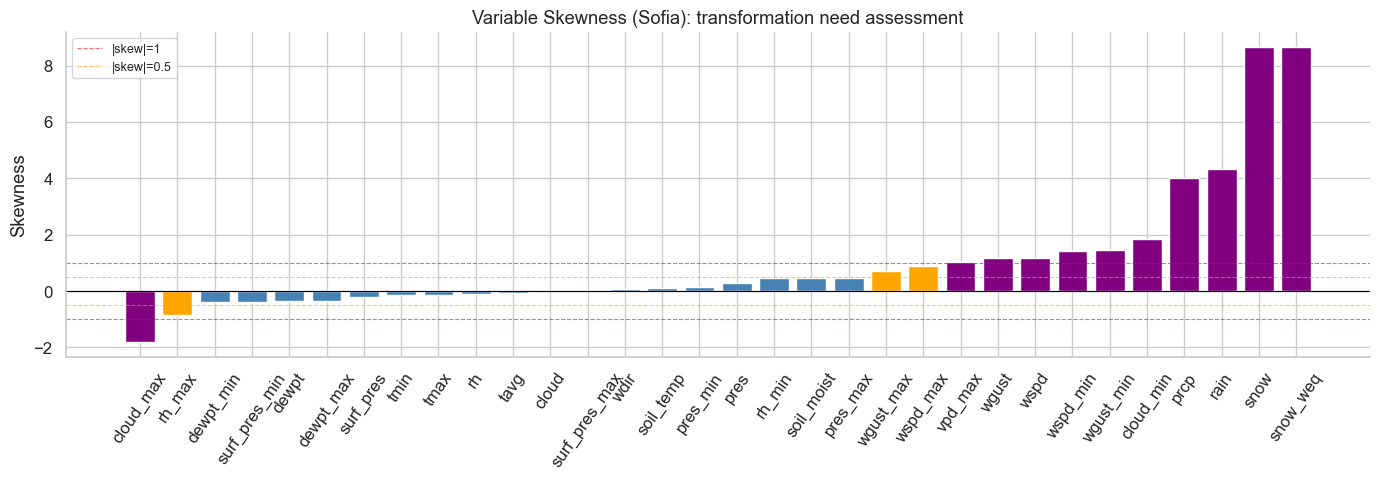

Saved: variable_skewness.png


In [22]:
# Skewness bar chart
fig, ax = plt.subplots(figsize=(14, 5))
skew_vals = summary['skewness'].sort_values()
colors = ['purple' if abs(v) >= 1 else ('orange' if abs(v) >= 0.5 else 'steelblue')
          for v in skew_vals.values]
ax.bar(skew_vals.index, skew_vals.values, color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(1, color='red', linestyle='--', linewidth=0.8, alpha=0.6, label='|skew|=1')
ax.axhline(-1, color='red', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axhline(0.5, color='orange', linestyle='--', linewidth=0.8, alpha=0.6, label='|skew|=0.5')
ax.axhline(-0.5, color='orange', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_title('Variable Skewness (Sofia): transformation need assessment')
ax.set_ylabel('Skewness')
ax.tick_params(axis='x', rotation=55)
ax.legend(fontsize=9)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'variable_skewness.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: variable_skewness.png')

### EDA Conclusion
This EDA confirms the 10-city Open-Meteo dataset is structurally sound: complete (no missing values, no date gaps), within physical plausibility bounds, and consistent across cities after column renaming. The dataset shows strong climatic diversity: Yundola's alpine regime, the coastal moderation of Varna and Burgas, and the continental dryness of the inland Danube-valley cities, which justifies a multi-city model with explicit geographic encoding (`elev`, `coastal`, `lat/lon`) rather than a single shared distribution assumption. 

Correlation analysis identifies `tmax`, `tmin`, `dewpt`, and `soil_temp` as strong same-day predictors of `tavg`, with `pres`, `cloud`, and `rh` as key synoptic drivers, while `soil_moist`, `vpd_max`, and `wdir` will require lagging or sin/cos decomposition before they contribute. Precipitation and wind variables are heavily right-skewed and zero-inflated, motivating log(1+x)/sqrt transforms and a two-stage occurrence-then-amount approach for the rain-classification task. 

The KS-test analysis led to a data-driven revision of the test window from the originally proposed 16-month span to a seasonally balanced calendar-year 2025 to avoid an artificial distribution shift, with 2026 retained only as a secondary recency check and Vidin's borderline shift flagged as a per-city caveat. Multicollinearity within the pressure, humidity, cloud, and wind variable groups (r > 0.85 - 0.97) is documented and flagged for VIF-based pruning during feature engineering. 

Taken together, these findings give a concrete, evidence-based hand-off to the feature-engineering notebook as next steps: which raw variables to keep, which to transform, which to drop, and how the train/validation/test split should be finalized.


### References

[1] World Meteorological Organization (2018). *Guide to Instruments and Methods of Observation* https://community.wmo.int/...guide-instruments-and-methods-of-observation-wmo-no-8

[2] Wilks, D.S. (2006). *Statistical Methods in the Atmospheric Sciences* (3rd ed.). Academic Press / Elsevier. https://sunandclimate.wordpress.com/wp-content/uploads/2009/05/statistical-methods-in-the-atmospheric-sciences-0127519661.pdf

[3] Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.) https://github.com/ageron/handson-ml3